In [ ]:
## 1. Functions

import torch, torch.nn.functional as F
import numpy as np
import re
import pandas as pd
import spacy
import matplotlib.pyplot as plt
import matplotlib.transforms as mtrans
import nltk
from datasets import load_dataset
from transformers import BertTokenizerFast, BertModel
from tqdm.notebook import tqdm
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize


def rmv_name_and_stopwd(text, person_name):
    doc = nlp(text)
    cleaned_tokens = []
    for token in doc:
      if token.ent_type_ in ["DATE", "TIME"]:
        cleaned_tokens.append(token.text_with_ws)
        continue
      if token.ent_type_ == "PERSON":
        person_name.add(token.text)
        continue
      if token.text.endswith("'s") or token.text in person_name:
        continue
      cleaned_tokens.append(token.text_with_ws)

    text_wo_entities = "".join(cleaned_tokens).strip()
    words = word_tokenize(text_wo_entities)
    filtered_words = [word for word in words if word.lower() not in stop_words]
    clean_text = " ".join(filtered_words)

    return clean_text, person_name


def sentence_split(text: str):
    text = text.strip()
    text = text.replace(",", "").replace("\"", "")  # remove comma and quotation marks
    pattern = r"[\n.!?]"                            # punctuations to split by
    sents = re.split(pattern, text)
    sents = [s.strip() for s in sents if s.strip()]
    return sents

# def words_and_sentence_ids(text: str):
#     """Return flat word list and per-word sentence id (0,1,2,...) using whitespace tokenization."""
#     sents = sentence_split(text)
#     words = []
#     sent_ids = []
#     for sid, s in enumerate(sents):
#         ws = s.split()  # split on space or even multiple spaces
#         print(f'Sentence #{sid+1}:', s)   # disabled the prints due to long output
#         print(f'Sentence #{sid+1}: word count {len(ws)}')
#         # print(f'Sentence #{sid+1} as a list: {ws}')
#         words.extend(ws)
#         sent_ids.extend([sid]*len(ws))
#     # print('words:', words)
#     # print('sent_ids:', sent_ids)
#     return words, sent_ids, sents


def select_outliers(series, series_sent_ids):

    x = np.asarray(series, dtype=float)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-8
    z = (x - med) / mad

    # progressively lower the (one-sided, lower-tail) threshold
    for thr in [-0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.25, -2.5, -3.0, -3.5]:
        idxs = np.where(z <= thr)[0].tolist()
        if len(idxs) < 2:
            continue
        # print(idxs)
        sents = {series_sent_ids[j] for j in idxs}
        if len(sents) == 2:  # or len(sents) == 3
            return idxs
    return None

# def per_word_contextual_embeddings(text: str):
#     if not text.strip():
#         return [], []
#     enc = tok(text, return_offsets_mapping=True, return_tensors="pt", add_special_tokens=True)
#     test_tokens = tok.convert_ids_to_tokens(enc['input_ids'][0])  # for checking sentence segmentation
#     print(test_tokens)
#     word_ids = enc.word_ids()

#     inputs = {k: v.to(DEVICE) for k, v in enc.items() if k in ("input_ids", "attention_mask", "token_type_ids")}

#     with torch.inference_mode():
#         out = mdl(**inputs)
#         token_h = out.last_hidden_state.squeeze(0).detach().cpu()  # (T, H) # why send to cpu?

#     words = text.split()
#     buckets = {}
#     for tidx, wid in enumerate(word_ids):
#         if wid is None:
#             continue
#         buckets.setdefault(wid, []).append(token_h[tidx])

#     word_vecs = []
#     for wid in range(len(words)):
#         if wid in buckets:
#             word_vecs.append(torch.stack(buckets[wid], dim=0).mean(dim=0))
#         else:
#             word_vecs.append(torch.zeros(token_h.shape[-1]))
#     return word_vecs


def moving_cosine_series(word_vecs, start_idx: int):
    """For i>=start_idx: cos(w_i, mean(w_0..w_{i-1}))."""
    if len(word_vecs) <= start_idx:
        return []
    running_sum = None
    series = []
    for i, v in enumerate(word_vecs):
        if running_sum is None:
            running_sum = v.clone()
            continue

        if i >= start_idx:
            mean_prev = running_sum / i
            cs = F.cosine_similarity(v, mean_prev, dim=0).item()
            series.append(cs)
        # print('running:',running_sum)
        # print('v:', v)
        running_sum = running_sum + v
    return series

def plot_mcs(series, words, sent_ids):
    token_names_for_plot = []
    # words = words[start_idx:]
    # sent_ids = sent_ids[start_idx:]

    for idx, word in enumerate(words):
        # xlabel = 'sen'+ str(sent_ids[idx]+1)+'_'+word
        xlabel = word
        if xlabel not in token_names_for_plot:
            token_names_for_plot.append(xlabel)
        else:
            suffix = 2
            xlabel_temp = xlabel
            while xlabel_temp in token_names_for_plot:
                  xlabel_temp = xlabel + str(suffix)
                  suffix += 1
            token_names_for_plot.append(xlabel_temp)


    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(token_names_for_plot, series)
    xtick_labels = ax.get_xticklabels()
    trans = mtrans.Affine2D().translate(8, 2)
    for t in xtick_labels:
        t.set_transform(t.get_transform() + trans)
    plt.xticks(rotation=90, ha='right')
    plt.grid(True)
    plt.show()


# def compute_M_for_text(text: str, plot: bool):
#     """
#       - A = 1 - cos(mean(all), mean(outliers))
#       - B = avg_i cos(o_i, mean(O \ {i}))
#       - M = (A + |B|)/3
#     If fewer than 2 sentences after the first, return M=0.
#     """
#     # Build word list + sentence ids (whitespace-based)
#     words, sent_ids, sents = words_and_sentence_ids(text)
#     # print(f'len(sents): {len(sents)}')
#     # print(f'len(words): {len(words)}')

#     if len(sents) < 2 or len(words) < 2:
#         print('error1')
#         return 0.0, 0.0, 0.0

#     flat_text = " ".join(words)
#     vecs = per_word_contextual_embeddings(flat_text)
#     if len(vecs) != len(words) or len(vecs) < 2:
#         print('error2')
#         return 0.0, 0.0, 0.0

#     # Start after sentence 1
#     first_sentence_word_count = sum(1 for sid in sent_ids if sid == 0)
#     start_idx = first_sentence_word_count
#     # print('start_idx:', start_idx)
#     series = moving_cosine_series(vecs, start_idx)

#     if not series:
#         print('error3')
#         return 0.0, 0.0, 0.0

#     series_sent_ids = [sent_ids[start_idx + j] for j in range(len(series))]
#     unique_after_first = sorted(set(series_sent_ids))
#     if len(unique_after_first) < 2:
#         print('error4')
#         return 0.0, 0.0, 0.0

#     if plot:
#         # print('series len:', len(series))
#         # print('words len:', len(words))
#         plot_mcs(series, words, sent_ids, start_idx)

#     # Compute per-sentence mean of series and pick the two lowest-mean sentences
#     outlier_positions = select_outliers(series, series_sent_ids)
#     if not outlier_positions:
#         print('error5: M=0 when two sentences are not found')
#         return 0.0, 0.0, 0.0  # per paper, M=0 if we can't find exactly two sentences

#     # Map back to original word indices
#     outlier_word_idxs = [start_idx + j for j in outlier_positions]
#     O = [vecs[i] for i in outlier_word_idxs]
#     # A = 1 - cos(mean(all), mean(O))
#     all_mean = torch.stack(vecs, dim=0).mean(dim=0)
#     out_mean = torch.stack(O, dim=0).mean(dim=0)
#     # print(f'all_mean: {all_mean}')
#     # print(f'out_mean: {out_mean}')
#     A = (1.0 - F.cosine_similarity(all_mean, out_mean, dim=0).item())

#     # B = avg over i in O of cos(o_i, mean(O \ {i}))
#     if len(O) == 1:
#         B = 0.0
#     else:
#         Ostack = torch.stack(O, dim=0)
#         sims = []
#         for i in range(len(O)):
#             others = torch.cat([Ostack[:i], Ostack[i+1:]], dim=0).mean(dim=0)
#             sims.append(F.cosine_similarity(Ostack[i], others, dim=0).item())
#         B = float(np.mean(sims))

#     M = (A + abs(B)) / 3.0
#     return float(M), float(A), float(B)

def compute_M(word_embeddings, moving_cosine_similarity, first_sentence_word_count, each_word_sent_id):
    """
      - A = 1 - cos(mean(all), mean(outliers))
      - B = avg_i cos(o_i, mean(O \ {i}))
      - M = (A + |B|)/3
    If fewer than 2 sentences after the first, return M=0.
    """

    # mcs_sent_ids = [each_word_sent_id[first_sentence_word_count + j] for j in range(len(moving_cosine_similarity))]
    mcs_sent_ids = each_word_sent_id[first_sentence_word_count:]
    unique_after_first = sorted(set(mcs_sent_ids))
    if len(unique_after_first) < 2:
        print('error4')
        return 0.0, 0.0, 0.0

    # Compute per-sentence mean of series and pick the two lowest-mean sentences
    outlier_positions = select_outliers(moving_cosine_similarity, mcs_sent_ids)
    if not outlier_positions:
        print('M=0, can not find two lowest moving cosine similarity values from two sentences')
        return 0.0, 0.0, 0.0  # per paper, M=0 if we can't find exactly two sentences

    # Map back to original word indices
    outlier_word_idxs = [first_sentence_word_count + j for j in outlier_positions]
    O = [word_embeddings[i] for i in outlier_word_idxs]
    # A = 1 - cos(mean(all), mean(O))
    all_mean = torch.stack(word_embeddings, dim=0).mean(dim=0)
    out_mean = torch.stack(O, dim=0).mean(dim=0)
    A = (1.0 - F.cosine_similarity(all_mean, out_mean, dim=0).item())

    # B = avg over i in O of cos(o_i, mean(O \ {i}))
    if len(O) == 1:
        B = 0.0
    else:
        Ostack = torch.stack(O, dim=0)
        sims = []
        for i in range(len(O)):
            others = torch.cat([Ostack[:i], Ostack[i+1:]], dim=0).mean(dim=0)
            sims.append(F.cosine_similarity(Ostack[i], others, dim=0).item())
        B = float(np.mean(sims))

    M = (A + abs(B)) / 3.0
    return float(M), float(A), float(B)


def build_table(results):
  df = pd.DataFrame(results, columns=["idx","M","A","B","text"])
  df_nonzero = df[df["M"] > 0].sort_values("M", ascending=True)

  num_total = len(df)
  num_nonzero = (df["M"] > 0).sum()
  ratio = (num_nonzero / num_total) if num_total else float('nan')
  print(f"Total stories processed: {num_total}")
  print(f"Stories with M ≠ 0: {num_nonzero}")
  print(f"Proportion with M ≠ 0: {ratio:.2%}")

  print("\nM summary:")
  print(df["M"].describe())
  print("Smallest non-zero M examples:")
  display(df_nonzero.head(5)[["M","A","B","text"]])
  print("Exact M=0 (or effectively 0) examples:")
  display(df[df["M"]==0].head(5)[["M","A","B","text"]])



def story_preprocess(story):
  story_split = sentence_split(story) # split the story (one string) to a list of sentences
  sentences = []


  person_name = {"Beep"}  # put Beep in the set manually because spacy failed to recognize this name
  # person_name = set()
  for sentence in story_split:
    sentence_processed, person_name = rmv_name_and_stopwd(sentence, person_name)
    sentences.append(sentence_processed)

  # tokenization
  encoded_input = tokenizer(sentences, return_tensors='pt', padding=True, truncation=True, add_special_tokens=True)
  input_ids = encoded_input['input_ids']
  attention_mask = encoded_input['attention_mask']

  # run BERT
  with torch.no_grad():
      output = model(**encoded_input)

  last_hidden_state = output.last_hidden_state   # last_hidden_state has a size = (batch_size, sequence_length, hidden_size)
                            # For a single sentence, batch_size will be 1. (I still get 1 with multiple sentence but I assume it wouldn't matter much)
                            # sequence_length corresponds to the number of tokens (including special tokens)
                            # hidden_size is the dimensionality of the embeddings (768 for bert-base-uncased, 1024 for bert-large-uncased).

  tokens_cleaned = []
  word_embeddings_cleaned = []
  each_word_sent_id = []
  first_sentence_word_count = 0

  for i, sentence in enumerate(sentences):
      sentence_embeddings = last_hidden_state[i]
      tokens = tokenizer.convert_ids_to_tokens(input_ids[i])
      word_ids = encoded_input.word_ids(i)

      current_word_embedding = []
      for j in range(len(tokens)):

          if attention_mask[i][j] == 1 and input_ids[i][j] != 101 and input_ids[i][j] != 102: # 101 is [CLS] and 102 is [SEP]
              if tokens[j].startswith('##'):
                  tokens_cleaned[-1] = tokens_cleaned[-1] + tokens[j][2:]
                  current_word_embedding.append(sentence_embeddings[j])
              else:
                  if current_word_embedding:
                      word_embeddings_cleaned.append(torch.mean(torch.stack(current_word_embedding), dim=0))
                  current_word_embedding = [sentence_embeddings[j]]
                  token_str = "sen" + str(i+1) + "_" + tokens[j]
                  tokens_cleaned.append(token_str)
                  # print(token_str,": ", token_embedding)
                  each_word_sent_id.append(i)
                  if i == 0:
                      first_sentence_word_count += 1
      if current_word_embedding: # add the last word's embedding
          word_embeddings_cleaned.append(torch.mean(torch.stack(current_word_embedding), dim=0))

  return tokens_cleaned, word_embeddings_cleaned, each_word_sent_id, first_sentence_word_count




def mcs(word_embeddings_cleaned, first_sentence_word_count, calculating_mcs_with_skipped_tokens):

  moving_cosine_similarity = []

  for i, word_vec in enumerate(word_embeddings_cleaned):

      if i < first_sentence_word_count:
          continue

      if calculating_mcs_with_skipped_tokens:
          all_previous_vectors_mean = torch.mean(torch.stack(word_embeddings_cleaned[:i]), dim=0)
      else:
          if i == first_sentence_word_count:
              all_previous_vectors_mean = word_vec
              print('Warning! First Moving Cosine Similarity is assumed to be 1.')
          else:
              all_previous_vectors_mean = torch.mean(torch.stack(word_embeddings_cleaned[first_sentence_word_count:i]), dim=0)

      cosine_similarity = F.cosine_similarity(all_previous_vectors_mean, word_vec, dim=0)
      moving_cosine_similarity.append(cosine_similarity.item())

  return moving_cosine_similarity


def no_quotations(text: str) -> bool:
  QUOTE_PATTERN = re.compile(r'[“”"]')  #filter quotation marks
  if not isinstance(text, str):
      return False
  return QUOTE_PATTERN.search(text) is None


<>:239: SyntaxWarning: invalid escape sequence '\ '
<>:239: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-1962296416.py:239: SyntaxWarning: invalid escape sequence '\ '
  - B = avg_i cos(o_i, mean(O \ {i}))


In [ ]:
## 2. Init

# BERT, base model has 768 dimensionality in word vectors, large has 1024 (the paper used 1024).
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)
tokenizer = BertTokenizerFast.from_pretrained("bert-large-uncased")
model = BertModel.from_pretrained("bert-large-uncased").to(DEVICE).eval()

# spacy, remove named entities
nlp = spacy.load("en_core_web_sm")
# !python -m spacy download en_core_web_lg
# nlp = spacy.load('en_core_web_lg')

# nltk, remove stop words
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

# load story
ds = load_dataset("roneneldan/TinyStories", split="train", streaming=True)



cpu


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Trying to filter stories we need(no quotations and M=0)

In [ ]:
## 3-1 Collect Raw Stories (M=0)

# hyperparams
MAX_STORIES = 100
PLOT = False #too long if set 2 true
calculating_mcs_with_skipped_tokens = True


results_m0 = []      #M == 0 and no_dialogue == True
processed = 0
kept_no_dialogue = 0
found_m0 = 0


for idx, ex in enumerate(ds):
    if processed >= MAX_STORIES or found_m0 == 9:
        break

    story = ex.get("text") or ex.get("story") or ""

    if not isinstance(story, str) or not story.strip():
        # skip empty
        continue

    processed += 1

    if not no_quotations(story):
        continue
    kept_no_dialogue += 1

    try:

        tokens, word_embeddings, each_word_sent_id, first_sentence_word_count = story_preprocess(story)
        moving_cosine_similarity = mcs(word_embeddings, first_sentence_word_count, calculating_mcs_with_skipped_tokens)
        M, A, B = compute_M(word_embeddings, moving_cosine_similarity, first_sentence_word_count, each_word_sent_id)

        if M == 0:
            results_m0.append((idx, M, A, B, story, True))
            found_m0 += 1
            if PLOT:
                plot_mcs(moving_cosine_similarity, tokens[first_sentence_word_count:], each_word_sent_id[first_sentence_word_count:])

    except Exception as e:
        print(f"[warn] error on story idx={idx}: {e}")



df_m0 = pd.DataFrame(
    results_m0,
    columns=["idx", "M", "A", "B", "text", "no_dialogue"]
)
print(f"No-quote stories kept:     {kept_no_dialogue}")
print(f"No-quote with M = 0:       {found_m0}")



print("\nExamples (no-quote & M=0):")
# display(df_m0.head(5)[["idx","M","A","B","text"]])
display(df_m0)
for i, row in enumerate(df_m0.head(9).itertuples(), start=1):
    print(f"\nStory {i}: (idx={row.idx}, M={row.M})")
    print(row.text)
    print("-" * 80)

M=0, can not find two lowest moving cosine similarity values from two sentences
M=0, can not find two lowest moving cosine similarity values from two sentences
M=0, can not find two lowest moving cosine similarity values from two sentences
M=0, can not find two lowest moving cosine similarity values from two sentences
M=0, can not find two lowest moving cosine similarity values from two sentences
M=0, can not find two lowest moving cosine similarity values from two sentences
M=0, can not find two lowest moving cosine similarity values from two sentences
M=0, can not find two lowest moving cosine similarity values from two sentences
M=0, can not find two lowest moving cosine similarity values from two sentences
No-quote stories kept:     14
No-quote with M = 0:       9

Examples (no-quote & M=0):


,idx,M,A,B,text,no_dialogue
0,1,0.0,0.0,0.0,"Once upon a time, there was a little car named...",True
1,4,0.0,0.0,0.0,"Once upon a time, there was a little girl name...",True
2,5,0.0,0.0,0.0,"Once upon a time, in a big lake, there was a b...",True
3,6,0.0,0.0,0.0,"Once upon a time, in a small town, there was a...",True
4,15,0.0,0.0,0.0,"Once upon a time, there was a queen. She was a...",True
5,18,0.0,0.0,0.0,"One day, a silly cat named Tom found a hoop in...",True
6,23,0.0,0.0,0.0,"Once upon a time, there was a helpful girl nam...",True
7,24,0.0,0.0,0.0,"Once upon a time, there was a little boy named...",True
8,27,0.0,0.0,0.0,"Once upon a time, there was a little boy named...",True



Story 1: (idx=1, M=0.0)
Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Beep liked how the leaves fall and wanted to play with them. Beep drove under the tree and watched the leaves fall on him. He laughed and beeped his horn.

Beep played with the falling leaves all day. When it was time to go home, Beep knew he needed more fuel. He went to the fuel place and got more healthy fuel. Now, Beep was ready to go fast and play again the next day. And Beep lived happily ever after.
--------------------------------------------------------------------------------

Story 2: (idx=4, M=0.0)
Once upon a time, there was a little girl named Lily. Lily liked to pretend she was a popular princess. She lived in a big castle with her best friends, a cat and 

In [ ]:
## Raw Stories Good for Insertion
"""
Story 1: (idx=1, M=0.0)
Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Beep liked how the leaves fall and wanted to play with them. Beep drove under the tree and watched the leaves fall on him. He laughed and beeped his horn.

Beep played with the falling leaves all day. When it was time to go home, Beep knew he needed more fuel. He went to the fuel place and got more healthy fuel. Now, Beep was ready to go fast and play again the next day. And Beep lived happily ever after.
--------------------------------------------------------------------------------

Story 2: (idx=4, M=0.0)
Once upon a time, there was a little girl named Lily. Lily liked to pretend she was a popular princess. She lived in a big castle with her best friends, a cat and a dog.

One day, while playing in the castle, Lily found a big cobweb. The cobweb was in the way of her fun game. She wanted to get rid of it, but she was scared of the spider that lived there.

Lily asked her friends, the cat and the dog, to help her. They all worked together to clean the cobweb. The spider was sad, but it found a new home outside. Lily, the cat, and the dog were happy they could play without the cobweb in the way. And they all lived happily ever after.
--------------------------------------------------------------------------------

Story 3: (idx=5, M=0.0)
Once upon a time, in a big lake, there was a brown kayak. The brown kayak liked to roll in the water all day long. It was very happy when it could roll and splash in the lake.

One day, a little boy named Tim came to play with the brown kayak. Tim and the brown kayak rolled in the water together. They laughed and had a lot of fun. The sun was shining, and the water was warm.

After a while, it was time for Tim to go home. He said goodbye to the brown kayak and gave it a big hug. The brown kayak was sad to see Tim go, but it knew they would play together again soon. So, the brown kayak kept rolling in the water, waiting for the next fun day with Tim.
--------------------------------------------------------------------------------

Story 4: (idx=6, M=0.0)
Once upon a time, in a small town, there was a troubled little girl named Lily. She was always sad because she lost her favorite toy, a triangle. She looked everywhere in her house but could not find it.

One sunny day, Lily went to the park to play. She saw a big puddle of water and thought her triangle might be there. She put her hand in the water to soak it and looked for her toy. She felt something at the bottom of the puddle.

Lily pulled it out and saw that it was her triangle! She was so happy that she found it. From that day on, Lily was never troubled again. She played with her triangle every day and always kept it close to her. And when she saw puddles, she would smile and remember how she found her toy.
--------------------------------------------------------------------------------

Story 5: (idx=15, M=0.0)
Once upon a time, there was a queen. She was a very nice queen. She had a big, pretty castle. The queen had a lot of work to do every day. But today, she wanted to relax.

The queen went to the park to relax. She sat on a soft, green grass. The queen saw a bug. The bug was disgusting. The queen did not like the disgusting bug.

The queen went back to her castle. She was happy to be away from the disgusting bug. Now, the queen could relax in her big, pretty castle. The queen smiled and had a good day.
--------------------------------------------------------------------------------

Story 6: (idx=18, M=0.0)
One day, a silly cat named Tom found a hoop in the yard. He wanted to play with it, but it was too big. Tom thought very hard about how to make the hoop smaller.

Tom had an idea. He would stretch the hoop to make it smaller. He put his paws on the hoop and pulled as hard as he could. The hoop started to stretch! It got smaller and smaller.

Now, the hoop was just the right size for Tom to play with. He jumped through the hoop and chased it around the yard. Tom had so much fun playing with his new toy. And that is the story of the silly cat and the hoop.
--------------------------------------------------------------------------------

Story 7: (idx=23, M=0.0)
Once upon a time, there was a helpful girl named Lily. She loved to read books and spend time with her friends. One day, she found a new book at school. The book was about a kind bear who helped everyone in the forest.

Lily read the book to her friends. They all liked the story. They wanted to be like the kind bear in the book. So, they decided to help others too. They helped their teacher clean the classroom. They also helped their friends when they fell down or needed a friend to play with.

As they spent more time being helpful, Lily and her friends felt happy. They learned that being kind and helpful to others made them happy too. The moral of the story is to be kind and helpful, just like the kind bear in the book.
--------------------------------------------------------------------------------

Story 8: (idx=24, M=0.0)
Once upon a time, there was a little boy named Tim. Tim wanted to build something special for his mom's birthday. He thought and thought about what to make. Then, he had an idea! He would build a big present for her.

Tim was worried. He didn't know if he could build the present all by himself. He asked his dad for help. Together, they found some big boxes, pretty paper, and a big bow. They worked together to make the present look nice.

When Tim's mom saw the present, she was so happy! She gave Tim a big hug and thanked him for the special gift. Tim felt proud that he could build something so nice for his mom. And he was no longer worried.
--------------------------------------------------------------------------------

Story 9: (idx=27, M=0.0)
Once upon a time, there was a little boy named Tim. Tim loved going to the park to play. One day, Tim went to the park with his mom and dad. He was very happy.

At the park, Tim saw a big tree. He wanted to give the tree a hug. So, he hugged the tree and felt good. Tim liked the tree a lot. He played with his ball, ran around, and had a lot of fun.

Tim had a successful day at the park. He played and laughed a lot. When it was time to go home, Tim felt tired but happy. He couldn't wait to come back to the park again.
--------------------------------------------------------------------------------
"""

"\nStory 1: (idx=1, M=0.0)\nOnce upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.\n\nOne day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Beep liked how the leaves fall and wanted to play with them. Beep drove under the tree and watched the leaves fall on him. He laughed and beeped his horn.\n\nBeep played with the falling leaves all day. When it was time to go home, Beep knew he needed more fuel. He went to the fuel place and got more healthy fuel. Now, Beep was ready to go fast and play again the next day. And Beep lived happily ever after.\n--------------------------------------------------------------------------------\n\nStory 2: (idx=4, M=0.0)\nOnce upon a time, there was a little girl named Lily. Lily liked to pretend she was a popular princess. She lived in a big castle with her best friends,

M=0, can not find two lowest moving cosine similarity values from two sentences


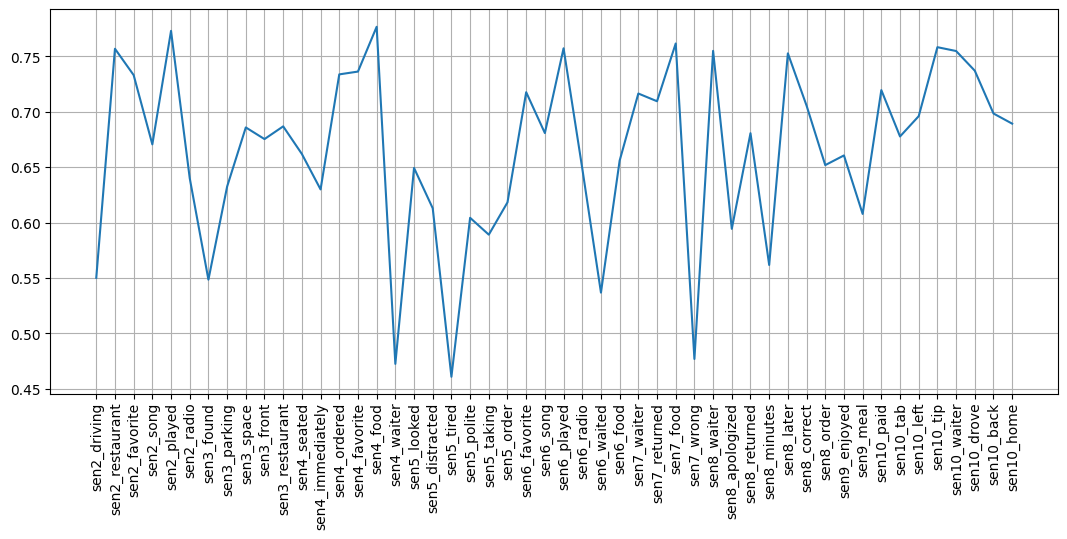

Total stories processed: 1
Stories with M ≠ 0: 0
Proportion with M ≠ 0: 0.00%

M summary:
count    1.0
mean     0.0
std      NaN
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
Name: M, dtype: float64
Smallest non-zero M examples:


,M,A,B,text


Exact M=0 (or effectively 0) examples:


,M,A,B,text
0,0.0,0.0,0.0,test


In [ ]:
## single story run

story = "Sam and Judy went out for dinner at their favorite restaurant. While driving to the restaurant, Judy's favorite song played on the radio. Sam found a parking space at the very front of the restaurant. Sam and Judy were seated immediately and ordered their favorite food to the waiter. He looked distracted and tired but was polite while taking their order. Sam's favorite song played on the radio while they waited for their food. When the waiter returned with their food it was all wrong! The waiter apologized and returned a few minutes later with the correct order. Sam and Judy enjoyed their meal. They paid their tab, left a tip for the waiter, and drove back home."

# story = """Once upon a time, there was a little boy named Tim. Tim loved going to the park to play. One day, Tim went to the park with his mom and dad. He was very happy.

# At the park, Tim saw a big tree. He wanted to give the tree a hug. So, he hugged the tree and felt good. Tim liked the tree a lot. He played with his ball, ran around, and had a lot of fun.

# Tim had a successful day at the park. He played and laughed a lot. When it was time to go home, Tim felt tired but happy. He couldn't wait to come back to the park again."""


calculating_mcs_with_skipped_tokens = True
results = []
tokens_cleaned, word_embeddings_cleaned, sent_ids, first_sentence_word_count = story_preprocess(story)
moving_cosine_similarity = mcs(word_embeddings_cleaned, first_sentence_word_count, calculating_mcs_with_skipped_tokens)
M, A, B = compute_M(word_embeddings_cleaned, moving_cosine_similarity, first_sentence_word_count, sent_ids)
results.append((0, M, A, B, "test"))
plot_mcs(moving_cosine_similarity, tokens_cleaned[first_sentence_word_count:], sent_ids[first_sentence_word_count:])
build_table(results)

# example story from the paper
# example = [
# "went dinner favorite restaurant",
# "driving restaurant favorite song played radio",
# "found parking space front restaurant",
# "seated immediately ordered favorite food waiter",
# "looked distracted tired polite taking order",
# "favorite song played radio waited food",
# "waiter returned food wrong",
# "waiter apologized returned minutes later correct order",
# "enjoyed meal",
# "paid tab left tip waiter drove back home"
# ]

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.
M=0, can not find two lowest moving cosine similarity values from two sentences


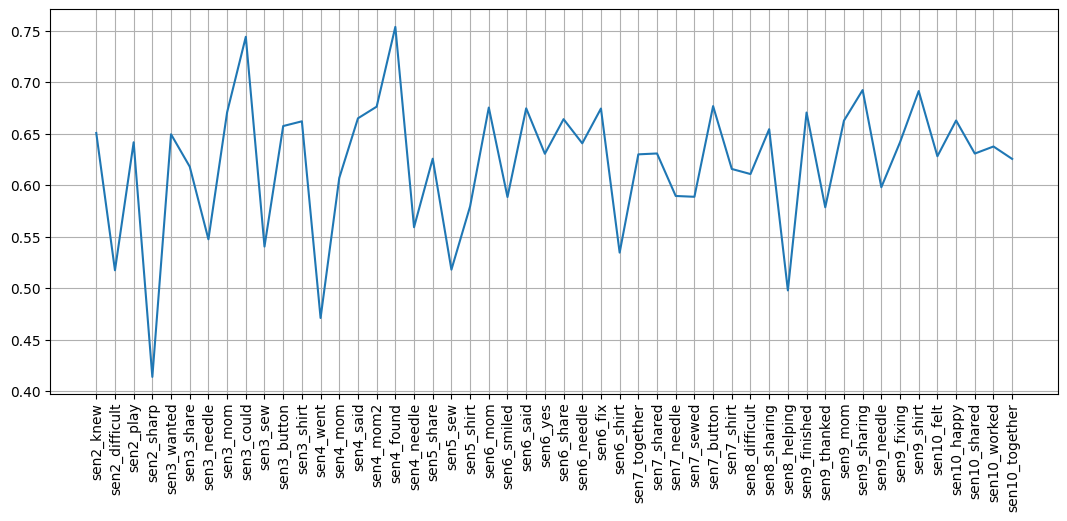

Total stories processed: 1
Stories with M ≠ 0: 0
Proportion with M ≠ 0: 0.00%

M summary:
count    1.0
mean     0.0
std      NaN
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
Name: M, dtype: float64
Smallest non-zero M examples:


,M,A,B,text


Exact M=0 (or effectively 0) examples:


,M,A,B,text
0,0.0,0.0,0.0,"One day, a little girl named Lily found a need..."


In [ ]:
## base
MAX_STORIES = 1  # try a small sample first
plot = True
calculating_mcs_with_skipped_tokens = True
results = []

for i, example in enumerate(ds):
    if i >= MAX_STORIES:
        break

    story = example.get("text") or example.get("story") or ""

    if not isinstance(story, str) or not story.strip():
        continue
    try:

        print(story)
        tokens, word_embeddings, each_word_sent_id, first_sentence_word_count = story_preprocess(story)

        moving_cosine_similarity = mcs(word_embeddings, first_sentence_word_count, calculating_mcs_with_skipped_tokens) # the returned mcs is skipped (if calculating_mcs_with_skipped_tokens = True)
        M, A, B = compute_M(word_embeddings, moving_cosine_similarity, first_sentence_word_count, each_word_sent_id)
        results.append((i, M, A, B, story))

    except Exception as e:
        print(f"error on story {i}: {e}")
    if plot:
        plot_mcs(moving_cosine_similarity, tokens[first_sentence_word_count:], each_word_sent_id[first_sentence_word_count:])

build_table(results)






**Last_modified**

In [ ]:
!pip install -q blingfire

In [ ]:
# @title Both In one story (no insertion at index 0)


import re, random
import pandas as pd
from blingfire import text_to_sentences
import nltk
from datasets import load_dataset


nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)


def sent_tokenize(text: str):
    if not text:
        return []
    sents = text_to_sentences(str(text)).split("\n")
    sents = [s.strip() for s in sents if s and s.strip()]
    return sents

def is_dialog_sentence(s: str):
    s = s.strip()
    if not s:
        return False
    return s.startswith(("\"", "“", "‘", "'")) or s.count('"') + s.count('“') + s.count('”') >= 2

def nearest_non_dialog_index(sents, idx):
    n = len(sents)
    if n == 0: return 0
    if idx >= n: idx = n - 1
    if not is_dialog_sentence(sents[idx]):
        return idx

    for d in range(1, max(idx, n - idx) + 1):
        left = idx - d
        right = idx + d
        if 0 <= left and not is_dialog_sentence(sents[left]): return left
        if right < n and not is_dialog_sentence(sents[right]): return right
    return min(idx, n - 1)

def avoid_zero_index(idx: int, n_sents: int) -> int:
    """
    Ensure we never use index 0 for insertion.
    If idx == 0 and there's at least 1 sentence, bump to 1.
    If n_sents == 0, return 0 (append-after behavior since there's no first sentence).
    """
    if n_sents == 0:
        return 0
    return 1 if idx == 0 else idx


PRONOUNY = {
    'someone','somebody','something','anyone','anybody','anything',
    'everyone','everybody','everything','noone','nobody','nothing',
    'thing','stuff','time','day','way','people','person','man','woman','guy'
}
STOP_LITE = {
    'the','a','an','and','but','or','nor','so','because','as','of','to','in','on','for','with',
    'from','at','by','into','over','after','before','between','through','during','without','about',
    'above','below','up','down','out','off','again','further'
}

def detect_tense(text):
    t = str(text).lower()
    past = len(re.findall(r"\b(was|were|did|had)\b", t))
    pres = len(re.findall(r"\b(is|are|does|has)\b", t))
    return "past" if past >= pres else "present"

def detect_pov(text):
    t = str(text).lower()
    c1 = len(re.findall(r"\b(i|me|my|mine|we|us|our|ours)\b", t))
    c2 = len(re.findall(r"\byou|your|yours\b", t))
    if c1 > c2 and c1 >= 2: return "first"
    if c2 > c1 and c2 >= 2: return "second"
    return "third"

def tokens_for_pos(text):
    return re.findall(r"[A-Za-z][A-Za-z'-]{1,}", str(text))

def looks_like_entity(token, is_sentence_start=False):

    return (not is_sentence_start) and token[:1].isupper()

def rank_common_nouns(text, sents, top_k=8):
    tokens = []
    for s in sents:
        words = re.findall(r"[A-Za-z][A-Za-z'-]{1,}", s)
        for i, w in enumerate(words):
            tokens.append((w, i == 0))
    if not tokens:
        return ["room","door","night","voice","letter","key"]

    just_tokens = [w for w,_ in tokens]
    tagged = nltk.pos_tag(just_tokens)

    freq, first_pos = {}, {}
    for idx, ((w, start_flag), (_, pos)) in enumerate(zip(tokens, tagged)):
        wl = w.lower()
        if pos not in ("NN", "NNS"):
            continue
        if wl in STOP_LITE or wl in PRONOUNY:
            continue
        if not wl.isalpha():
            continue
        if looks_like_entity(w, is_sentence_start=start_flag):
            continue
        freq[wl] = freq.get(wl, 0) + 1
        first_pos.setdefault(wl, idx)

    if not freq:
        return ["room","door","night","voice","letter","key"]

    max_idx = max(first_pos.values()) or 1
    scores = {w: (freq[w] + 0.5*(1 - first_pos[w]/max_idx)) for w in freq}
    ranked = sorted(scores, key=lambda w: (-scores[w], w))
    return ranked[:top_k]


def ensure_one_sentence(s: str) -> str:
    sents = sent_tokenize(s)
    if not sents:
        return ""
    one = sents[0].strip()
    if one and one[-1] not in ".?!…":
        one += "."
    return one

def anywhere_index(n_sents: int, rng) -> int:
    """
    Choose an insertion point in [1..n_sents], so index 0 is never selected.
    n_sents means 'after the story'.
    If the story is empty (n_sents == 0), return 0 to allow append-after.
    """
    if n_sents <= 0:
        return 0
    return rng.randint(1, n_sents)

def splice_preserving_original(original_text: str, sents: list[str], insert_sent: str, idx: int) -> str:
    """
    Preserve original story verbatim; insert between sentence boundaries
    or append after without reformatting the original.
    """
    if idx >= len(sents):  # append after
        sep = "" if original_text.endswith((" ", "\n")) else " "
        return f"{original_text}{sep}{insert_sent}"

    left = " ".join(sents[:idx]).strip()
    right = " ".join(sents[idx:]).strip()
    if left and right:
        return f"{left} {insert_sent} {right}"
    elif left:
        return f"{left} {insert_sent}"
    elif right:
        return f"{insert_sent} {right}"
    else:
        return insert_sent


def det_phrase(noun): return f"the {noun}"
def pluralize_if_needed(noun): return noun

def make_hint(theme_words, tense="past", pov="third", rng=None):
    rng = rng or random
    w = pluralize_if_needed(rng.choice(theme_words))
    wdet = det_phrase(w)
    if tense == "past":
        base = [
            f"Earlier, there was a small detail about {wdet} that didn't sit right.",
            f"Before long, a quiet remark about {wdet} was easy to overlook.",
            f"At the time, {wdet} seemed ordinary, but something felt off.",
            f"No one noticed {wdet} then, tucked slightly out of place."
        ]
    else:
        base = [
            f"At first, something about {wdet} doesn’t add up.",
            f"There’s a quiet remark about {wdet} that’s easy to overlook.",
            f"{wdet.capitalize()} looks ordinary, but something feels off.",
            f"Nobody notices {wdet}, just slightly out of place."
        ]
    if pov == "first":
        base += [f"I should have paid more attention to {wdet}."]
    elif pov == "second":
        base += [f"You might overlook {wdet}, but it matters."]
    return ensure_one_sentence(rng.choice(base))

def make_twist(theme_words, tense="past", pov="third", rng=None):
    rng = rng or random
    w = pluralize_if_needed(rng.choice(theme_words))
    wdet = det_phrase(w)
    if tense == "past":
        base = [
            f"Only later did it become clear: {wdet} was never what they thought.",
            f"In the end, {wdet} belonged to someone else entirely.",
            f"Then the truth snapped into place—{wdet} had been the misdirection.",
            f"It turned out {wdet} was missing for a reason no one would admit."
        ]
    else:
        base = [
            f"Only now is it clear: {wdet} isn’t what they think.",
            f"In the end, {wdet} belongs to someone else entirely.",
            f"The truth snaps into place—{wdet} is the misdirection.",
            f"{wdet.capitalize()} is missing for a reason no one will admit."
        ]
    if pov == "first":
        base += [f"I finally see it now—{wdet} changes everything."]
    elif pov == "second":
        base += [f"Now you can see it—{wdet} was pointing the other way."]
    return ensure_one_sentence(rng.choice(base))


def augment_story_both(story_id, story_text, rng):
    sents = sent_tokenize(story_text)
    n = len(sents)

    tense = detect_tense(story_text)
    pov = detect_pov(story_text)
    theme_words = rank_common_nouns(story_text, sents, top_k=8)

    hint_sent = make_hint(theme_words, tense=tense, pov=pov, rng=rng)
    twist_sent = make_twist(theme_words, tense=tense, pov=pov, rng=rng)


    raw_hint = anywhere_index(n, rng)
    raw_twist = anywhere_index(n, rng)


    if raw_hint < n:
        hint_idx = nearest_non_dialog_index(sents, raw_hint)
        hint_idx = avoid_zero_index(hint_idx, n)
    else:
        hint_idx = n  # append

    if raw_twist < n:
        twist_idx = nearest_non_dialog_index(sents, raw_twist)
        twist_idx = avoid_zero_index(twist_idx, n)
    else:
        twist_idx = n


    first_kind, first_sent, first_idx = ("hint", hint_sent, hint_idx)
    second_kind, second_sent, second_idx = ("twist", twist_sent, twist_idx)
    if twist_idx < hint_idx:
        first_kind, first_sent, first_idx, second_kind, second_sent, second_idx = \
            ("twist", twist_sent, twist_idx, "hint", hint_sent, hint_idx)


    out_text = splice_preserving_original(story_text, sents, first_sent, first_idx)


    if second_idx == n:
        second_idx_translated = n + 1
    else:
        if first_idx < n and second_idx > first_idx:
            second_idx_translated = second_idx + 1
        else:
            second_idx_translated = second_idx


    sents_updated = sent_tokenize(out_text)
    out_text = splice_preserving_original(out_text, sents_updated, second_sent, second_idx_translated)

    meta = {
        "story_id": story_id,
        "variant_type": "hint+twist",
        "inserted_hint": hint_sent,
        "inserted_twist": twist_sent,
        "hint_index_original": int(hint_idx),
        "twist_index_original": int(twist_idx),
        "hint_appended_after": bool(hint_idx >= n),
        "twist_appended_after": bool(twist_idx >= n),
        "tense_guess": tense,
        "pov_guess": pov,
        "theme_words": "|".join(theme_words),
    }
    return out_text, meta


ds = load_dataset("roneneldan/TinyStories", split="train", streaming=True)

rng = random.Random(123)
rows = []
count = 0

for i, sample in enumerate(ds):
    if count >= 20:
        break
    story_id = f"s{i+1}"
    text = sample["text"]

    sents_check = sent_tokenize(text)
    if len(sents_check) == 0:

        pass

    aug_text, meta = augment_story_both(story_id, text, rng)
    rows.append({**meta, "original_text": text, "augmented_text": aug_text})
    count += 1


def mark_once(text, sent):
    return re.sub(re.escape(sent.strip()), f"[INS: {sent.strip()}]", text, count=1)
print(rows[0])
# for r in rows:
#     marked = mark_once(mark_once(r["augmented_text"], r["inserted_hint"]), r["inserted_twist"])
#     print("="*100)
#     print(f"{r['story_id']} — HINT idx {r['hint_index_original']} (append={r['hint_appended_after']}), "
#           f"TWIST idx {r['twist_index_original']} (append={r['twist_appended_after']})")
#     print("— inserted HINT: ", r["inserted_hint"])
#     print("— inserted TWIST:", r["inserted_twist"])
#     print("\n--- ORIGINAL ---\n" + r["original_text"])
#     print("\n--- AUGMENTED (marked) ---\n" + marked)
#     print("="*100 + "\n")


{'story_id': 's1', 'variant_type': 'hint+twist', 'inserted_hint': 'At the time, the shirt seemed ordinary, but something felt off.', 'inserted_twist': 'It turned out the shirt was missing for a reason no one would admit.', 'hint_index_original': 4, 'twist_index_original': 2, 'hint_appended_after': False, 'twist_appended_after': False, 'tense_guess': 'past', 'pov_guess': 'first', 'theme_words': 'shirt|mom|share|needle|button|girl|room', 'original_text': 'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping 

In [ ]:

# 3 Variations Per Story

import re, random
import pandas as pd
import nltk
from datasets import load_dataset


try:
    from blingfire import text_to_sentences as _bfsent
    def text_to_sentences(text: str) -> str:
        return _bfsent(text)
except Exception:
    # Fallback to NLTK sentence tokenizer
    nltk.download("punkt", quiet=True)
    from nltk.tokenize import sent_tokenize as _nltk_sent_tokenize
    def text_to_sentences(text: str) -> str:
        return "\n".join(_nltk_sent_tokenize(text))


nltk.download("averaged_perceptron_tagger", quiet=True)

try:
    nltk.download("averaged_perceptron_tagger_eng", quiet=True)
except Exception:
    pass

from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)


def sent_tokenize(text: str):
    if not text:
        return []
    sents = text_to_sentences(str(text)).split("\n")
    sents = [s.strip() for s in sents if s and s.strip()]
    return sents

def is_dialog_sentence(s: str):
    s = s.strip()
    if not s:
        return False
    return s.startswith(("\"", "“", "‘", "'")) or s.count('"') + s.count('“') + s.count('”') >= 2

def nearest_non_dialog_index(sents, idx):
    n = len(sents)
    if n == 0: return 0
    if idx >= n: idx = n - 1
    if not is_dialog_sentence(sents[idx]):
        return idx

    for d in range(1, max(idx, n - idx) + 1):
        left = idx - d
        right = idx + d
        if 0 <= left and not is_dialog_sentence(sents[left]): return left
        if right < n and not is_dialog_sentence(sents[right]): return right
    return min(idx, n - 1)

def avoid_zero_index(idx: int, n_sents: int) -> int:
    """
    Ensure we never use index 0 for insertion.
    If idx == 0 and there's at least 1 sentence, bump to 1.
    If n_sents == 0, return 0 (append-after behavior since there's no first sentence).
    """
    if n_sents == 0:
        return 0
    return 1 if idx == 0 else idx

PRONOUNY = {
    'someone','somebody','something','anyone','anybody','anything',
    'everyone','everybody','everything','noone','nobody','nothing',
    'thing','stuff','time','day','way','people','person','man','woman','guy'
}
STOP_LITE = {
    'the','a','an','and','but','or','nor','so','because','as','of','to','in','on','for','with',
    'from','at','by','into','over','after','before','between','through','during','without','about',
    'above','below','up','down','out','off','again','further'
}

def detect_tense(text):
    t = str(text).lower()
    past = len(re.findall(r"\b(was|were|did|had)\b", t))
    pres = len(re.findall(r"\b(is|are|does|has)\b", t))
    return "past" if past >= pres else "present"

def detect_pov(text):
    t = str(text).lower()
    c1 = len(re.findall(r"\b(i|me|my|mine|we|us|our|ours)\b", t))
    c2 = len(re.findall(r"\byou|your|yours\b", t))
    if c1 > c2 and c1 >= 2: return "first"
    if c2 > c1 and c2 >= 2: return "second"
    return "third"

def tokens_for_pos(text):
    return re.findall(r"[A-Za-z][A-Za-z'-]{1,}", str(text))

def looks_like_entity(token, is_sentence_start=False):
    return (not is_sentence_start) and token[:1].isupper()

def rank_common_nouns(text, sents, top_k=8):
    tokens = []
    for s in sents:
        words = re.findall(r"[A-Za-z][A-Za-z'-]{1,}", s)
        for i, w in enumerate(words):
            tokens.append((w, i == 0))
    if not tokens:
        return ["room","door","night","voice","letter","key"]

    just_tokens = [w for w,_ in tokens]
    tagged = nltk.pos_tag(just_tokens)

    freq, first_pos = {}, {}
    for idx, ((w, start_flag), (_, pos)) in enumerate(zip(tokens, tagged)):
        wl = w.lower()
        if pos not in ("NN", "NNS"):
            continue
        if wl in STOP_LITE or wl in PRONOUNY:
            continue
        if not wl.isalpha():
            continue
        if looks_like_entity(w, is_sentence_start=start_flag):
            continue
        freq[wl] = freq.get(wl, 0) + 1
        first_pos.setdefault(wl, idx)

    if not freq:
        return ["room","door","night","voice","letter","key"]

    max_idx = max(first_pos.values()) or 1
    scores = {w: (freq[w] + 0.5*(1 - first_pos[w]/max_idx)) for w in freq}
    ranked = sorted(scores, key=lambda w: (-scores[w], w))
    return ranked[:top_k]

def ensure_one_sentence(s: str) -> str:
    sents = sent_tokenize(s)
    if not sents:
        return ""
    one = sents[0].strip()
    if one and one[-1] not in ".?!…":
        one += "."
    return one

def anywhere_index(n_sents: int, rng) -> int:
    """
    Choose an insertion point in [1..n_sents], so index 0 is never selected.
    n_sents means 'after the story'.
    If the story is empty (n_sents == 0), return 0 to allow append-after.
    """
    if n_sents <= 0:
        return 0
    return rng.randint(1, n_sents)

def splice_preserving_original(original_text: str, sents, insert_sent: str, idx: int) -> str:
    """
    Preserve original story verbatim; insert between sentence boundaries
    or append after without reformatting the original.
    """
    if idx >= len(sents):  # append after
        sep = "" if original_text.endswith((" ", "\n")) else " "
        return f"{original_text}{sep}{insert_sent}"

    left = " ".join(sents[:idx]).strip()
    right = " ".join(sents[idx:]).strip()
    if left and right:
        return f"{left} {insert_sent} {right}"
    elif left:
        return f"{left} {insert_sent}"
    elif right:
        return f"{insert_sent} {right}"
    else:
        return insert_sent

def det_phrase(noun): return f"the {noun}"
def pluralize_if_needed(noun): return noun

def make_hint(theme_words, tense="past", pov="third", rng=None):
    rng = rng or random
    w = pluralize_if_needed(rng.choice(theme_words))
    wdet = det_phrase(w)
    if tense == "past":
        base = [
            f"Earlier, there was a small detail about {wdet} that didn't sit right.",
            f"Before long, a quiet remark about {wdet} was easy to overlook.",
            f"At the time, {wdet} seemed ordinary, but something felt off.",
            f"No one noticed {wdet} then, tucked slightly out of place."
        ]
    else:
        base = [
            f"At first, something about {wdet} doesn’t add up.",
            f"There’s a quiet remark about {wdet} that’s easy to overlook.",
            f"{wdet.capitalize()} looks ordinary, but something feels off.",
            f"Nobody notices {wdet}, just slightly out of place."
        ]
    if pov == "first":
        base += [f"I should have paid more attention to {wdet}."]
    elif pov == "second":
        base += [f"You might overlook {wdet}, but it matters."]
    return ensure_one_sentence(rng.choice(base))

def make_twist(theme_words, tense="past", pov="third", rng=None):
    rng = rng or random
    w = pluralize_if_needed(rng.choice(theme_words))
    wdet = det_phrase(w)
    if tense == "past":
        base = [
            f"Only later did it become clear: {wdet} was never what they thought.",
            f"In the end, {wdet} belonged to someone else entirely.",
            f"Then the truth snapped into place—{wdet} had been the misdirection.",
            f"It turned out {wdet} was missing for a reason no one would admit."
        ]
    else:
        base = [
            f"Only now is it clear: {wdet} isn’t what they think.",
            f"In the end, {wdet} belongs to someone else entirely.",
            f"The truth snaps into place—{wdet} is the misdirection.",
            f"{wdet.capitalize()} is missing for a reason no one will admit."
        ]
    if pov == "first":
        base += [f"I finally see it now—{wdet} changes everything."]
    elif pov == "second":
        base += [f"Now you can see it—{wdet} was pointing the other way."]
    return ensure_one_sentence(rng.choice(base))

# ---------- Augmenters ----------
def augment_story_hint(story_id, story_text, rng):
    sents = sent_tokenize(story_text)
    n = len(sents)
    tense = detect_tense(story_text)
    pov = detect_pov(story_text)
    theme_words = rank_common_nouns(story_text, sents, top_k=8)

    hint_sent = make_hint(theme_words, tense=tense, pov=pov, rng=rng)
    raw_hint = anywhere_index(n, rng)

    if raw_hint < n:
        hint_idx = nearest_non_dialog_index(sents, raw_hint)
        hint_idx = avoid_zero_index(hint_idx, n)
    else:
        hint_idx = n

    out_text = splice_preserving_original(story_text, sents, hint_sent, hint_idx)

    meta = {
        "story_id": story_id,
        "variant_type": "hint_only",
        "inserted_hint": hint_sent,
        "inserted_twist": "",
        "hint_index_original": int(hint_idx),
        "twist_index_original": -1,
        "hint_appended_after": bool(hint_idx >= n),
        "twist_appended_after": False,
        "tense_guess": tense,
        "pov_guess": pov,
        "theme_words": "|".join(theme_words),
    }
    return out_text, meta

def augment_story_twist(story_id, story_text, rng):
    sents = sent_tokenize(story_text)
    n = len(sents)
    tense = detect_tense(story_text)
    pov = detect_pov(story_text)
    theme_words = rank_common_nouns(story_text, sents, top_k=8)

    twist_sent = make_twist(theme_words, tense=tense, pov=pov, rng=rng)
    raw_twist = anywhere_index(n, rng)

    if raw_twist < n:
        twist_idx = nearest_non_dialog_index(sents, raw_twist)
        twist_idx = avoid_zero_index(twist_idx, n)
    else:
        twist_idx = n

    out_text = splice_preserving_original(story_text, sents, twist_sent, twist_idx)

    meta = {
        "story_id": story_id,
        "variant_type": "twist_only",
        "inserted_hint": "",
        "inserted_twist": twist_sent,
        "hint_index_original": -1,
        "twist_index_original": int(twist_idx),
        "hint_appended_after": False,
        "twist_appended_after": bool(twist_idx >= n),
        "tense_guess": detect_tense(story_text),
        "pov_guess": detect_pov(story_text),
        "theme_words": "|".join(theme_words),
    }
    return out_text, meta

def augment_story_both(story_id, story_text, rng):
    sents = sent_tokenize(story_text)
    n = len(sents)

    tense = detect_tense(story_text)
    pov = detect_pov(story_text)
    theme_words = rank_common_nouns(story_text, sents, top_k=8)

    hint_sent = make_hint(theme_words, tense=tense, pov=pov, rng=rng)
    twist_sent = make_twist(theme_words, tense=tense, pov=pov, rng=rng)

    raw_hint = anywhere_index(n, rng)
    raw_twist = anywhere_index(n, rng)

    if raw_hint < n:
        hint_idx = nearest_non_dialog_index(sents, raw_hint)
        hint_idx = avoid_zero_index(hint_idx, n)
    else:
        hint_idx = n  # append

    if raw_twist < n:
        twist_idx = nearest_non_dialog_index(sents, raw_twist)
        twist_idx = avoid_zero_index(twist_idx, n)
    else:
        twist_idx = n

    # Order insertions so indices remain correct
    first_kind, first_sent, first_idx = ("hint", hint_sent, hint_idx)
    second_kind, second_sent, second_idx = ("twist", twist_sent, twist_idx)
    if twist_idx < hint_idx:
        first_kind, first_sent, first_idx, second_kind, second_sent, second_idx = \
            ("twist", twist_sent, twist_idx, "hint", hint_sent, hint_idx)

    out_text = splice_preserving_original(story_text, sents, first_sent, first_idx)

    if second_idx == n:
        second_idx_translated = n + 1  # append-after moves by 1 after first insert
    else:
        if first_idx < n and second_idx > first_idx:
            second_idx_translated = second_idx + 1
        else:
            second_idx_translated = second_idx

    sents_updated = sent_tokenize(out_text)
    out_text = splice_preserving_original(out_text, sents_updated, second_sent, second_idx_translated)

    meta = {
        "story_id": story_id,
        "variant_type": "hint+twist",
        "inserted_hint": hint_sent,
        "inserted_twist": twist_sent,
        "hint_index_original": int(hint_idx),
        "twist_index_original": int(twist_idx),
        "hint_appended_after": bool(hint_idx >= n),
        "twist_appended_after": bool(twist_idx >= n),
        "tense_guess": tense,
        "pov_guess": pov,
        "theme_words": "|".join(theme_words),
    }
    return out_text, meta

def mark_once(text, sent):

    return re.sub(re.escape(sent.strip()), f"[INS: {sent.strip()}]", text, count=1)


# ds = load_dataset("roneneldan/TinyStories", split="train", streaming=True)

# rng_master = random.Random(123)
# rows = []
# stories_to_process = 20
# count = 0

# for i, sample in enumerate(ds):
#     if count >= stories_to_process:
#         break

#     story_id = f"s{i+1}"
#     text = sample["text"] or ""


#     sents_check = sent_tokenize(text)
#     if len(sents_check) == 0:
#         continue


#     rng_hint = random.Random(rng_master.random())
#     rng_twist = random.Random(rng_master.random())
#     rng_both = random.Random(rng_master.random())


#     aug_hint_text, meta_hint = augment_story_hint(story_id, text, rng_hint)
#     rows.append({**meta_hint, "original_text": text, "augmented_text": aug_hint_text})


#     aug_twist_text, meta_twist = augment_story_twist(story_id, text, rng_twist)
#     rows.append({**meta_twist, "original_text": text, "augmented_text": aug_twist_text})


#     aug_both_text, meta_both = augment_story_both(story_id, text, rng_both)
#     rows.append({**meta_both, "original_text": text, "augmented_text": aug_both_text})

#     count += 1


# print("Total augmented rows:", len(rows))
# print(rows[0])


# sample_row = next((r for r in rows if r["variant_type"] == "hint+twist"), None)
# if sample_row:
#     marked = mark_once(mark_once(sample_row["augmented_text"], sample_row["inserted_hint"]),
#                        sample_row["inserted_twist"])
#     print("="*100)
#     print(f"{sample_row['story_id']} — HINT idx {sample_row['hint_index_original']} (append={sample_row['hint_appended_after']}), "
#           f"TWIST idx {sample_row['twist_index_original']} (append={sample_row['twist_appended_after']})")
#     print("— inserted HINT: ", sample_row["inserted_hint"])
#     print("— inserted TWIST:", sample_row["inserted_twist"])
#     print("\n--- ORIGINAL ---\n" + sample_row["original_text"])
#     print("\n--- AUGMENTED (marked) ---\n" + marked)
#     print("="*100 + "\n")

# # Optional: DataFrame
# df = pd.DataFrame(rows)
# # df.head()
# # df.to_csv("augmented_tinystories_variations.csv", index=False)


In [ ]:

# print(df_m0.head())
rng_master = random.Random(123)
NUM_VARIATIONS_PER_STORY = 3             # hint+twist versions per story
stories_to_process = 20                  # base stories
rows = []
count = 0


for idx, row in df_m0.iterrows():
    if idx >= 20:
        break
    # print(type(row['text']))
    text = row['text']

    sents_check = sent_tokenize(text)
    if len(sents_check) == 0:
        pass


    for j in range(NUM_VARIATIONS_PER_STORY):
        seed = int(rng_master.random() * 1e9) + j
        rng_both = random.Random(seed)

        aug_both_text, meta_both = augment_story_both(story_id, text, rng_both)

        meta_both["variant_index"] = j
        rows.append({**meta_both, "original_text": text, "augmented_text": aug_both_text,"story_id":idx})

    count += 1
print(rows[0])

{'story_id': 0, 'variant_type': 'hint+twist', 'inserted_hint': 'At the time, the tree seemed ordinary, but something felt off.', 'inserted_twist': 'It turned out the tree was missing for a reason no one would admit.', 'hint_index_original': 3, 'twist_index_original': 7, 'hint_appended_after': False, 'twist_appended_after': False, 'tense_guess': 'past', 'pov_guess': 'third', 'theme_words': 'fuel|leaves|car|tree|sun|park|fall|drove', 'variant_index': 0, 'original_text': 'Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.\n\nOne day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Beep liked how the leaves fall and wanted to play with them. Beep drove under the tree and watched the leaves fall on him. He laughed and beeped his horn.\n\nBeep played with the falling leaves all day. When it was time to go h

In [ ]:
display(df_m0)


,idx,M,A,B,text,no_dialogue
0,1,0.0,0.0,0.0,"Once upon a time, there was a little car named...",True
1,4,0.0,0.0,0.0,"Once upon a time, there was a little girl name...",True
2,5,0.0,0.0,0.0,"Once upon a time, in a big lake, there was a b...",True
3,6,0.0,0.0,0.0,"Once upon a time, in a small town, there was a...",True
4,15,0.0,0.0,0.0,"Once upon a time, there was a queen. She was a...",True
5,18,0.0,0.0,0.0,"One day, a silly cat named Tom found a hoop in...",True
6,23,0.0,0.0,0.0,"Once upon a time, there was a helpful girl nam...",True
7,24,0.0,0.0,0.0,"Once upon a time, there was a little boy named...",True
8,27,0.0,0.0,0.0,"Once upon a time, there was a little boy named...",True


Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Beep liked how the leaves fall and wanted to play with them. Beep drove under the tree and watched the leaves fall on him. He laughed and beeped his horn.

Beep played with the falling leaves all day. When it was time to go home, Beep knew he needed more fuel. He went to the fuel place and got more healthy fuel. Now, Beep was ready to go fast and play again the next day. And Beep lived happily ever after.
M=0, can not find two lowest moving cosine similarity values from two sentences


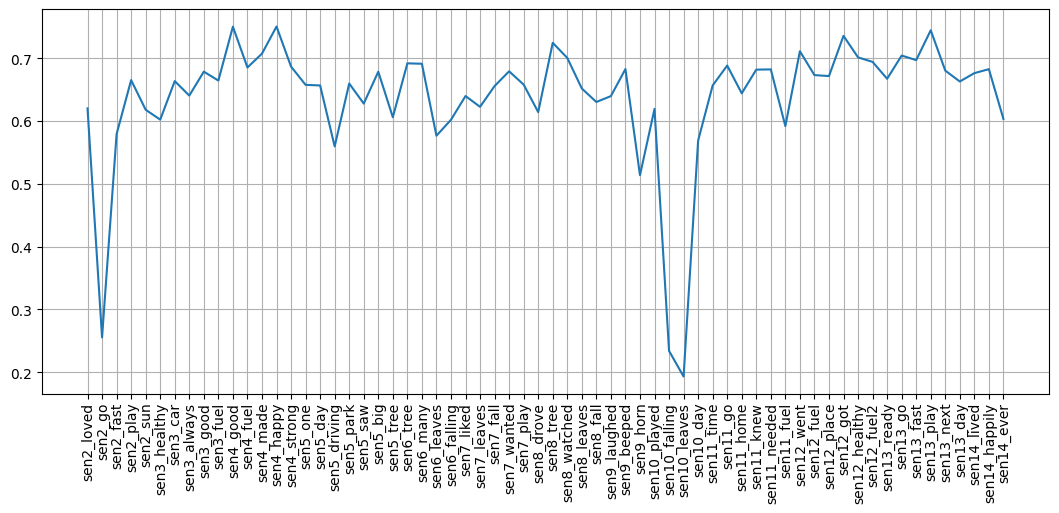

Once upon a time, there was a little girl named Lily. Lily liked to pretend she was a popular princess. She lived in a big castle with her best friends, a cat and a dog.

One day, while playing in the castle, Lily found a big cobweb. The cobweb was in the way of her fun game. She wanted to get rid of it, but she was scared of the spider that lived there.

Lily asked her friends, the cat and the dog, to help her. They all worked together to clean the cobweb. The spider was sad, but it found a new home outside. Lily, the cat, and the dog were happy they could play without the cobweb in the way. And they all lived happily ever after.
M=0, can not find two lowest moving cosine similarity values from two sentences


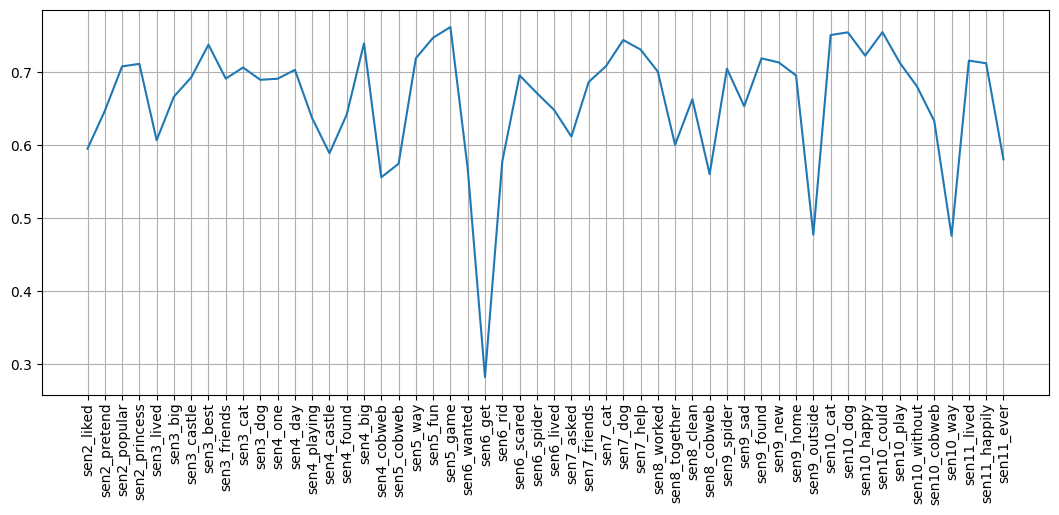

Once upon a time, in a big lake, there was a brown kayak. The brown kayak liked to roll in the water all day long. It was very happy when it could roll and splash in the lake.

One day, a little boy named Tim came to play with the brown kayak. Tim and the brown kayak rolled in the water together. They laughed and had a lot of fun. The sun was shining, and the water was warm.

After a while, it was time for Tim to go home. He said goodbye to the brown kayak and gave it a big hug. The brown kayak was sad to see Tim go, but it knew they would play together again soon. So, the brown kayak kept rolling in the water, waiting for the next fun day with Tim.
M=0, can not find two lowest moving cosine similarity values from two sentences


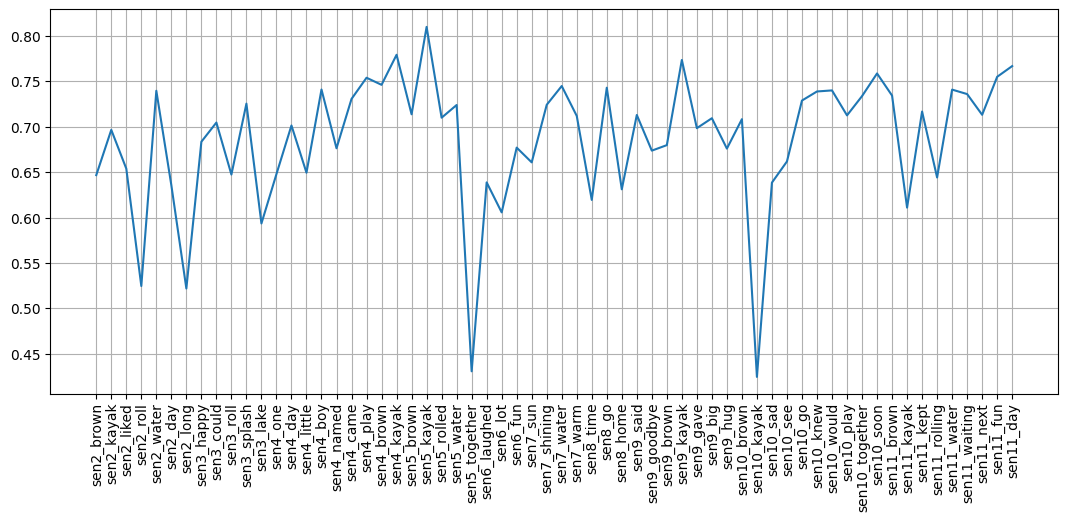

Once upon a time, in a small town, there was a troubled little girl named Lily. She was always sad because she lost her favorite toy, a triangle. She looked everywhere in her house but could not find it.

One sunny day, Lily went to the park to play. She saw a big puddle of water and thought her triangle might be there. She put her hand in the water to soak it and looked for her toy. She felt something at the bottom of the puddle.

Lily pulled it out and saw that it was her triangle! She was so happy that she found it. From that day on, Lily was never troubled again. She played with her triangle every day and always kept it close to her. And when she saw puddles, she would smile and remember how she found her toy.
M=0, can not find two lowest moving cosine similarity values from two sentences


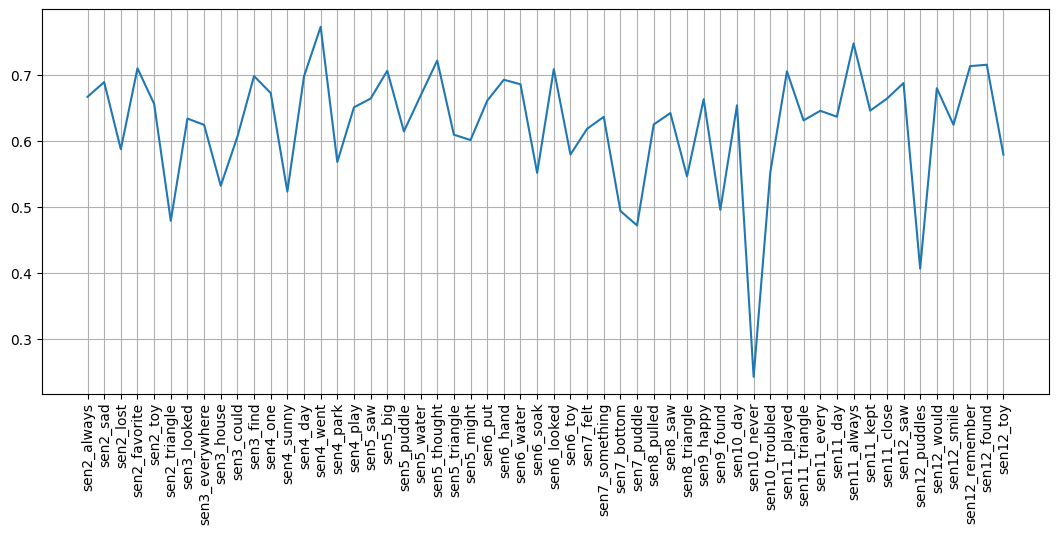

Once upon a time, there was a queen. She was a very nice queen. She had a big, pretty castle. The queen had a lot of work to do every day. But today, she wanted to relax.

The queen went to the park to relax. She sat on a soft, green grass. The queen saw a bug. The bug was disgusting. The queen did not like the disgusting bug.

The queen went back to her castle. She was happy to be away from the disgusting bug. Now, the queen could relax in her big, pretty castle. The queen smiled and had a good day.
M=0, can not find two lowest moving cosine similarity values from two sentences


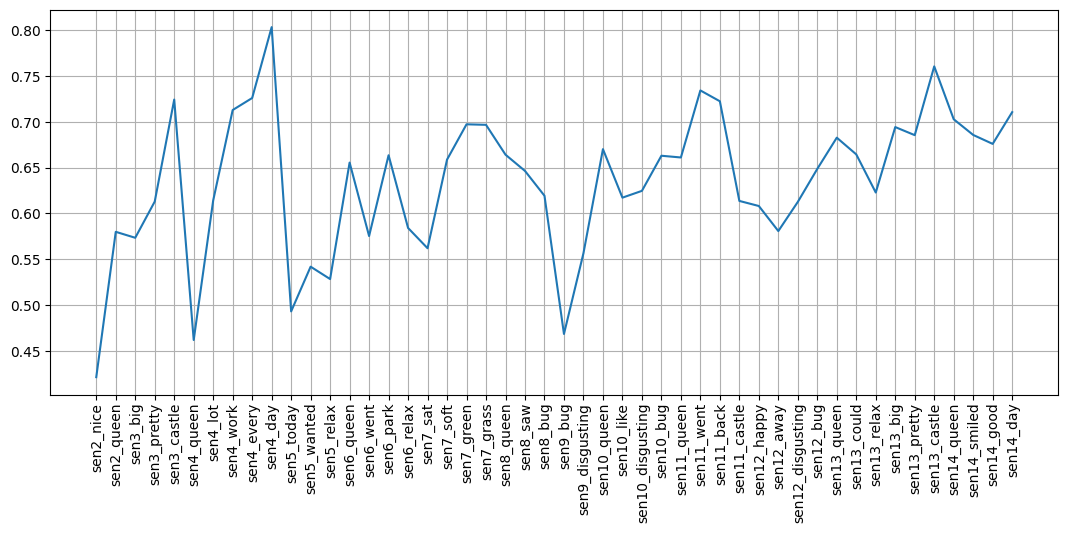

One day, a silly cat named Tom found a hoop in the yard. He wanted to play with it, but it was too big. Tom thought very hard about how to make the hoop smaller.

Tom had an idea. He would stretch the hoop to make it smaller. He put his paws on the hoop and pulled as hard as he could. The hoop started to stretch! It got smaller and smaller.

Now, the hoop was just the right size for Tom to play with. He jumped through the hoop and chased it around the yard. Tom had so much fun playing with his new toy. And that is the story of the silly cat and the hoop.
M=0, can not find two lowest moving cosine similarity values from two sentences


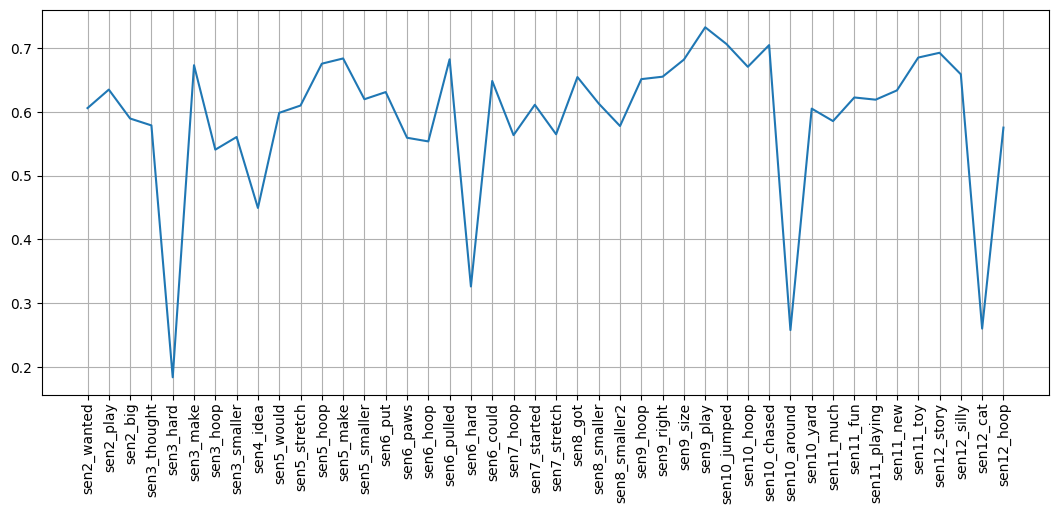

Once upon a time, there was a helpful girl named Lily. She loved to read books and spend time with her friends. One day, she found a new book at school. The book was about a kind bear who helped everyone in the forest.

Lily read the book to her friends. They all liked the story. They wanted to be like the kind bear in the book. So, they decided to help others too. They helped their teacher clean the classroom. They also helped their friends when they fell down or needed a friend to play with.

As they spent more time being helpful, Lily and her friends felt happy. They learned that being kind and helpful to others made them happy too. The moral of the story is to be kind and helpful, just like the kind bear in the book.
M=0, can not find two lowest moving cosine similarity values from two sentences


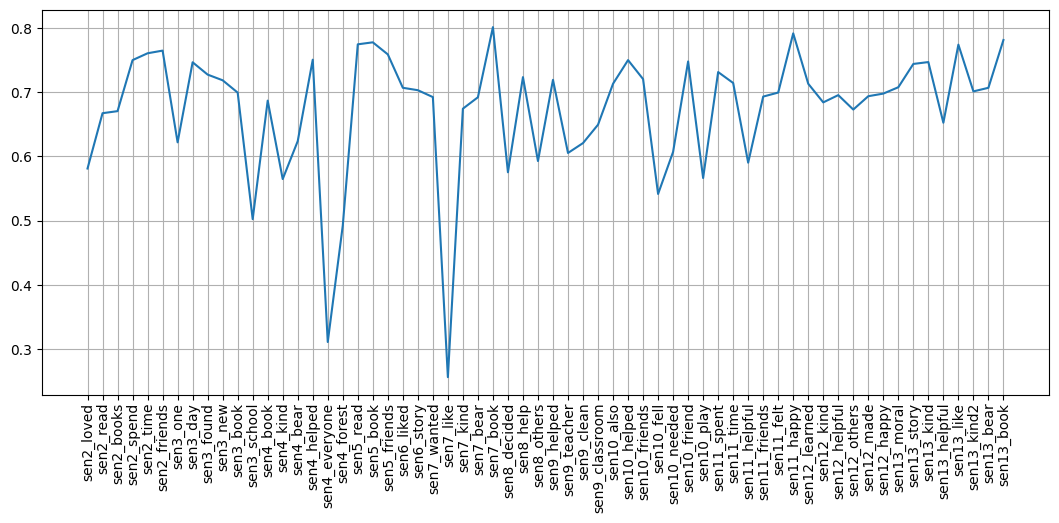

Once upon a time, there was a little boy named Tim. Tim wanted to build something special for his mom's birthday. He thought and thought about what to make. Then, he had an idea! He would build a big present for her.

Tim was worried. He didn't know if he could build the present all by himself. He asked his dad for help. Together, they found some big boxes, pretty paper, and a big bow. They worked together to make the present look nice.

When Tim's mom saw the present, she was so happy! She gave Tim a big hug and thanked him for the special gift. Tim felt proud that he could build something so nice for his mom. And he was no longer worried.
M=0, can not find two lowest moving cosine similarity values from two sentences


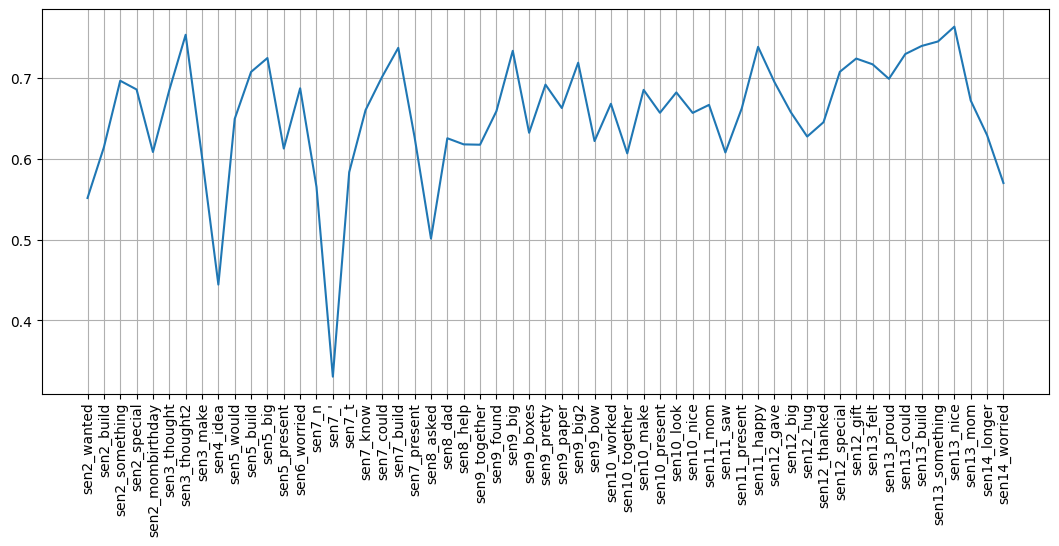

Once upon a time, there was a little boy named Tim. Tim loved going to the park to play. One day, Tim went to the park with his mom and dad. He was very happy.

At the park, Tim saw a big tree. He wanted to give the tree a hug. So, he hugged the tree and felt good. Tim liked the tree a lot. He played with his ball, ran around, and had a lot of fun.

Tim had a successful day at the park. He played and laughed a lot. When it was time to go home, Tim felt tired but happy. He couldn't wait to come back to the park again.
M=0, can not find two lowest moving cosine similarity values from two sentences


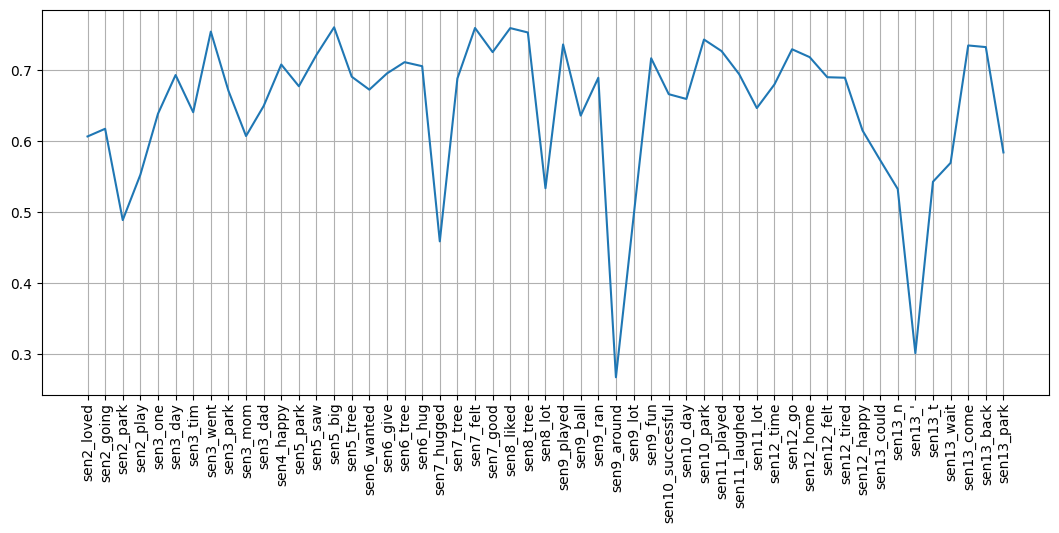

Total stories processed: 9
Stories with M ≠ 0: 0
Proportion with M ≠ 0: 0.00%

M summary:
count    9.0
mean     0.0
std      0.0
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
Name: M, dtype: float64
Smallest non-zero M examples:


,M,A,B,text


Exact M=0 (or effectively 0) examples:


,M,A,B,text
0,0.0,0.0,0.0,"Once upon a time, there was a little car named..."
1,0.0,0.0,0.0,"Once upon a time, there was a little girl name..."
2,0.0,0.0,0.0,"Once upon a time, in a big lake, there was a b..."
3,0.0,0.0,0.0,"Once upon a time, in a small town, there was a..."
4,0.0,0.0,0.0,"Once upon a time, there was a queen. She was a..."


In [ ]:
## base over df_0
# MAX_STORIES =
plot = True
calculating_mcs_with_skipped_tokens = True
results = []
i = 0
for idx, row in df_m0.iterrows():
    # print(type(row['text']))
    story = row["text"]

    # if i >= MAX_STORIES:
    #     break
    if not isinstance(story, str) or not story.strip():
        continue
    try:

        print(story)
        tokens, word_embeddings, each_word_sent_id, first_sentence_word_count = story_preprocess(story)

        moving_cosine_similarity = mcs(word_embeddings, first_sentence_word_count, calculating_mcs_with_skipped_tokens)
        M, A, B = compute_M(word_embeddings, moving_cosine_similarity, first_sentence_word_count, each_word_sent_id)
        results.append((i, M, A, B, story))
        i +=1

    except Exception as e:
        print(f"error on story {i}: {e}")
    if plot:
        plot_mcs(moving_cosine_similarity, tokens[first_sentence_word_count:], each_word_sent_id[first_sentence_word_count:])

build_table(results)






In [ ]:
rows

[{'story_id': 0,
  'variant_type': 'hint+twist',
  'inserted_hint': 'At the time, the tree seemed ordinary, but something felt off.',
  'inserted_twist': 'It turned out the tree was missing for a reason no one would admit.',
  'hint_index_original': 3,
  'twist_index_original': 7,
  'hint_appended_after': False,
  'twist_appended_after': False,
  'tense_guess': 'past',
  'pov_guess': 'third',
  'theme_words': 'fuel|leaves|car|tree|sun|park|fall|drove',
  'variant_index': 0,
  'original_text': 'Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.\n\nOne day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Beep liked how the leaves fall and wanted to play with them. Beep drove under the tree and watched the leaves fall on him. He laughed and beeped his horn.\n\nBeep played with the falling leaves all day.

Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. At the time, the tree seemed ordinary, but something felt off. Good fuel made Beep happy and strong. One day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Beep liked how the leaves fall and wanted to play with them. It turned out the tree was missing for a reason no one would admit. Beep drove under the tree and watched the leaves fall on him. He laughed and beeped his horn. Beep played with the falling leaves all day. When it was time to go home, Beep knew he needed more fuel. He went to the fuel place and got more healthy fuel. Now, Beep was ready to go fast and play again the next day. And Beep lived happily ever after.
M=0, can not find two lowest moving cosine similarity values from two sentences


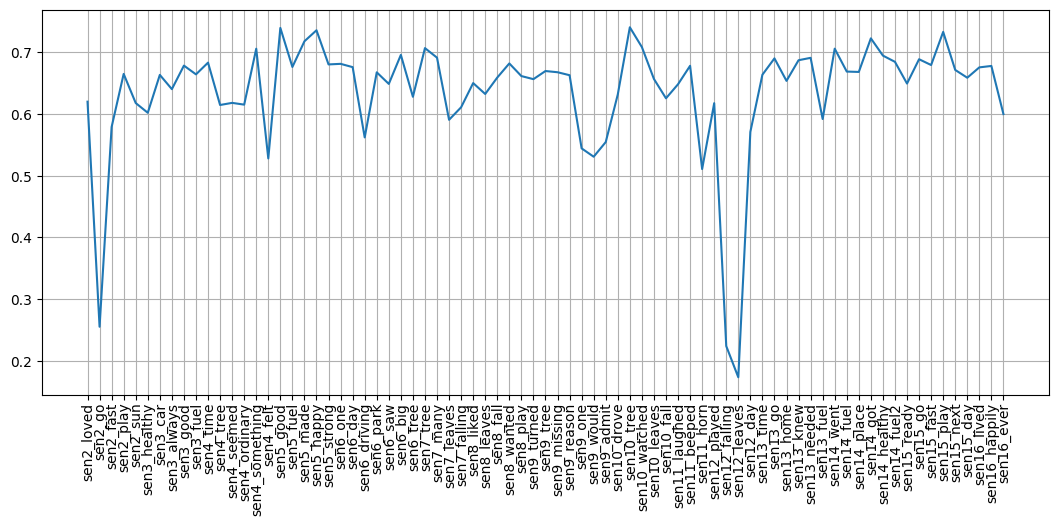

Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. No one noticed the park then, tucked slightly out of place. Beep was a healthy car because he always had good fuel. It turned out the sun was missing for a reason no one would admit. Good fuel made Beep happy and strong. One day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Beep liked how the leaves fall and wanted to play with them. Beep drove under the tree and watched the leaves fall on him. He laughed and beeped his horn. Beep played with the falling leaves all day. When it was time to go home, Beep knew he needed more fuel. He went to the fuel place and got more healthy fuel. Now, Beep was ready to go fast and play again the next day. And Beep lived happily ever after.
M=0, can not find two lowest moving cosine similarity values from two sentences


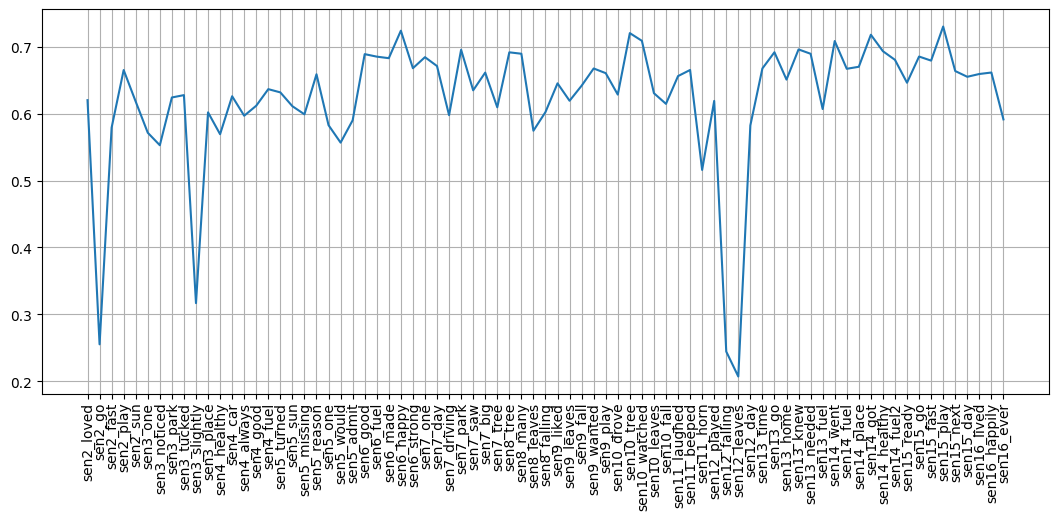

Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong. One day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Beep liked how the leaves fall and wanted to play with them. Beep drove under the tree and watched the leaves fall on him. Then the truth snapped into place—the sun had been the misdirection. Earlier, there was a small detail about the leaves that didn't sit right. He laughed and beeped his horn. Beep played with the falling leaves all day. When it was time to go home, Beep knew he needed more fuel. He went to the fuel place and got more healthy fuel. Now, Beep was ready to go fast and play again the next day. And Beep lived happily ever after.
M=0, can not find two lowest moving cosine similarity values from two sentences


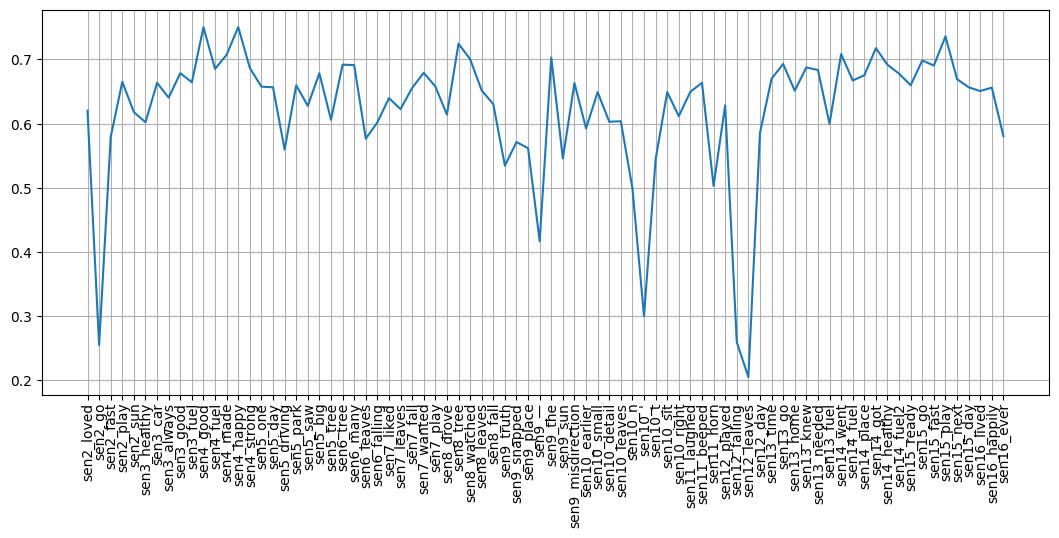

Once upon a time, there was a little girl named Lily. Lily liked to pretend she was a popular princess. At the time, the dog seemed ordinary, but something felt off. She lived in a big castle with her best friends, a cat and a dog. One day, while playing in the castle, Lily found a big cobweb. The cobweb was in the way of her fun game. She wanted to get rid of it, but she was scared of the spider that lived there. Lily asked her friends, the cat and the dog, to help her. They all worked together to clean the cobweb. The spider was sad, but it found a new home outside. Only later did it become clear: the girl was never what they thought. Lily, the cat, and the dog were happy they could play without the cobweb in the way. And they all lived happily ever after.
M=0, can not find two lowest moving cosine similarity values from two sentences


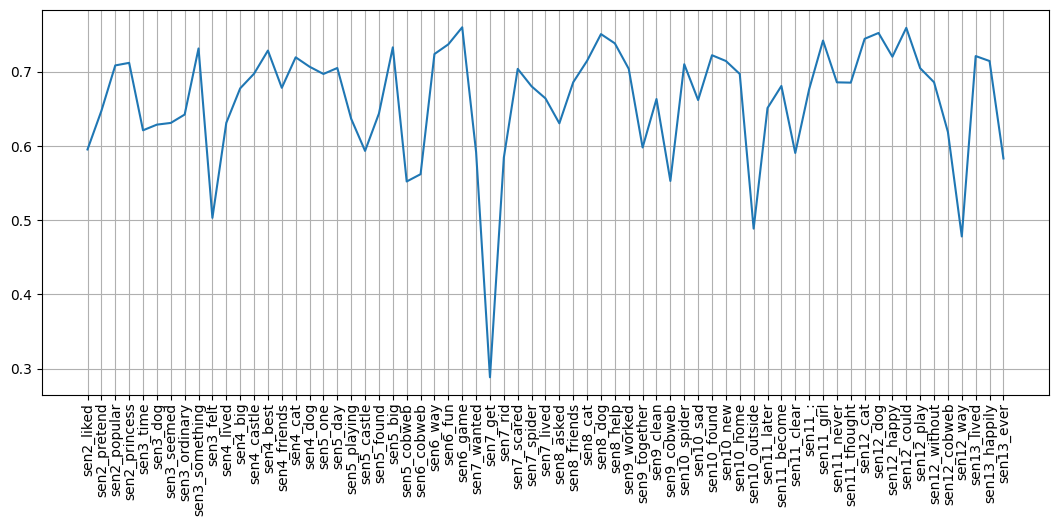

Once upon a time, there was a little girl named Lily. Lily liked to pretend she was a popular princess. No one noticed the cat then, tucked slightly out of place. She lived in a big castle with her best friends, a cat and a dog. One day, while playing in the castle, Lily found a big cobweb. The cobweb was in the way of her fun game. In the end, the princess belonged to someone else entirely. She wanted to get rid of it, but she was scared of the spider that lived there. Lily asked her friends, the cat and the dog, to help her. They all worked together to clean the cobweb. The spider was sad, but it found a new home outside. Lily, the cat, and the dog were happy they could play without the cobweb in the way. And they all lived happily ever after.
M=0, can not find two lowest moving cosine similarity values from two sentences


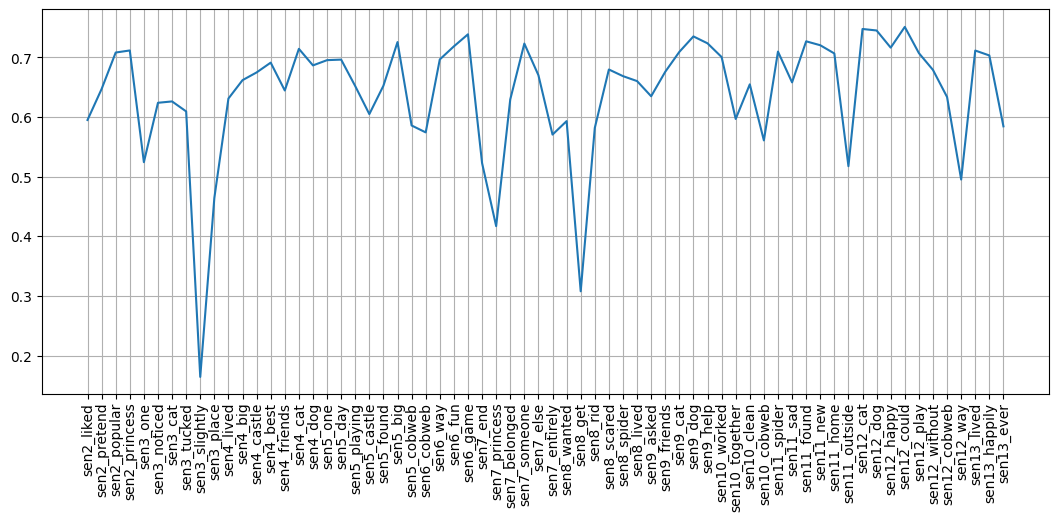

Once upon a time, there was a little girl named Lily. Lily liked to pretend she was a popular princess. She lived in a big castle with her best friends, a cat and a dog. One day, while playing in the castle, Lily found a big cobweb. The cobweb was in the way of her fun game. She wanted to get rid of it, but she was scared of the spider that lived there. Lily asked her friends, the cat and the dog, to help her. They all worked together to clean the cobweb. It turned out the dog was missing for a reason no one would admit. Earlier, there was a small detail about the princess that didn't sit right. The spider was sad, but it found a new home outside. Lily, the cat, and the dog were happy they could play without the cobweb in the way. And they all lived happily ever after.
M=0, can not find two lowest moving cosine similarity values from two sentences


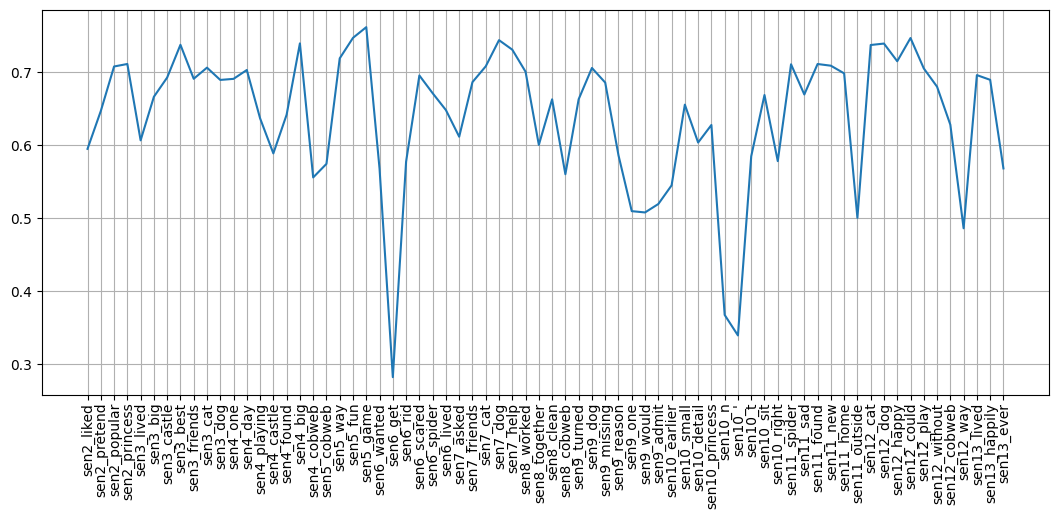

Once upon a time, in a big lake, there was a brown kayak. The brown kayak liked to roll in the water all day long. It was very happy when it could roll and splash in the lake. One day, a little boy named Tim came to play with the brown kayak. Tim and the brown kayak rolled in the water together. They laughed and had a lot of fun. The sun was shining, and the water was warm. Before long, a quiet remark about the kayak was easy to overlook. After a while, it was time for Tim to go home. He said goodbye to the brown kayak and gave it a big hug. The brown kayak was sad to see Tim go, but it knew they would play together again soon. So, the brown kayak kept rolling in the water, waiting for the next fun day with Tim. Then the truth snapped into place—the boy had been the misdirection.
M=0, can not find two lowest moving cosine similarity values from two sentences


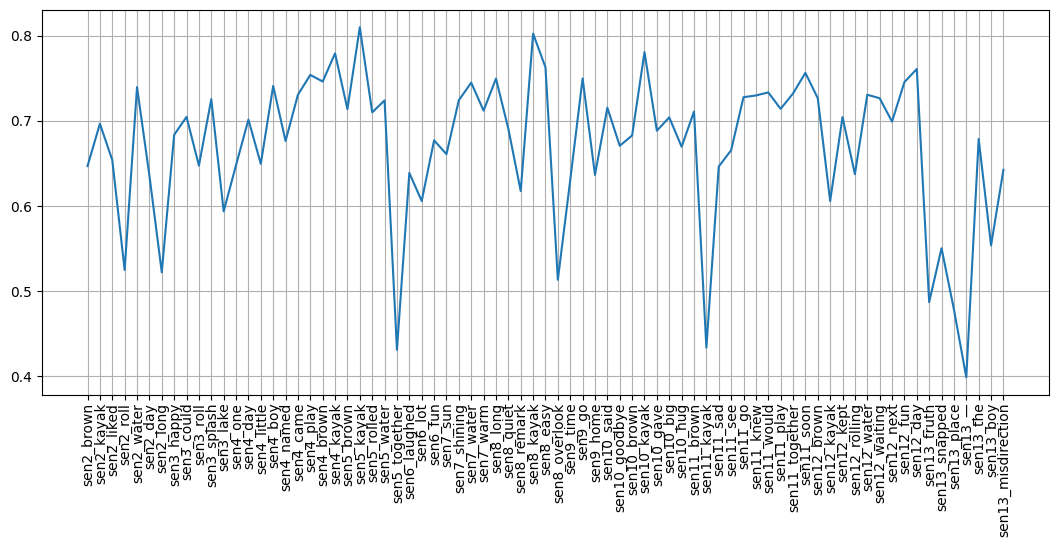

Once upon a time, in a big lake, there was a brown kayak. The brown kayak liked to roll in the water all day long. It was very happy when it could roll and splash in the lake. One day, a little boy named Tim came to play with the brown kayak. Earlier, there was a small detail about the water that didn't sit right. Tim and the brown kayak rolled in the water together. They laughed and had a lot of fun. The sun was shining, and the water was warm. After a while, it was time for Tim to go home. He said goodbye to the brown kayak and gave it a big hug. The brown kayak was sad to see Tim go, but it knew they would play together again soon. So, the brown kayak kept rolling in the water, waiting for the next fun day with Tim. Then the truth snapped into place—the home had been the misdirection.
M=0, can not find two lowest moving cosine similarity values from two sentences


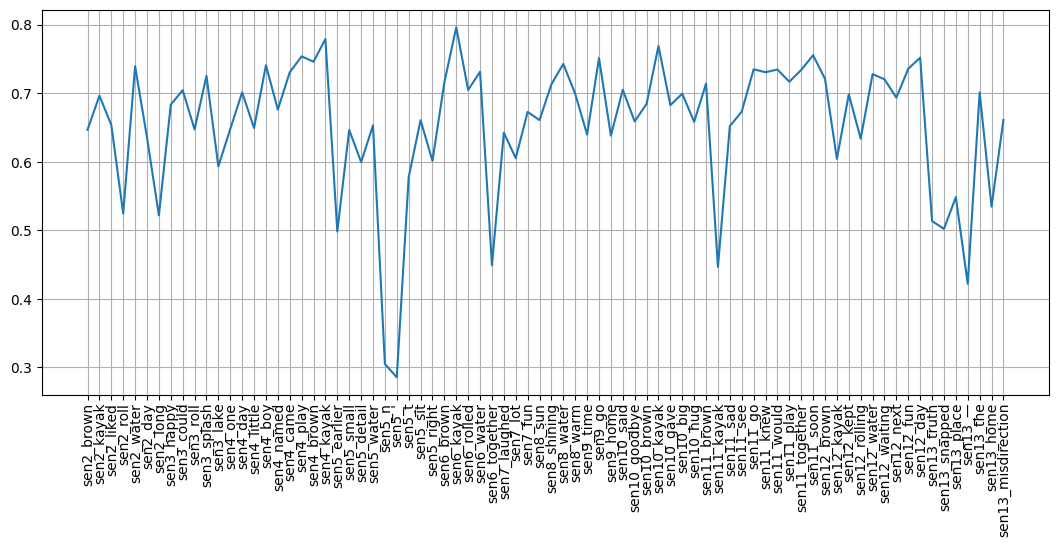

Once upon a time, in a big lake, there was a brown kayak. The brown kayak liked to roll in the water all day long. Then the truth snapped into place—the water had been the misdirection. It was very happy when it could roll and splash in the lake. One day, a little boy named Tim came to play with the brown kayak. At the time, the water seemed ordinary, but something felt off. Tim and the brown kayak rolled in the water together. They laughed and had a lot of fun. The sun was shining, and the water was warm. After a while, it was time for Tim to go home. He said goodbye to the brown kayak and gave it a big hug. The brown kayak was sad to see Tim go, but it knew they would play together again soon. So, the brown kayak kept rolling in the water, waiting for the next fun day with Tim.
M=0, can not find two lowest moving cosine similarity values from two sentences


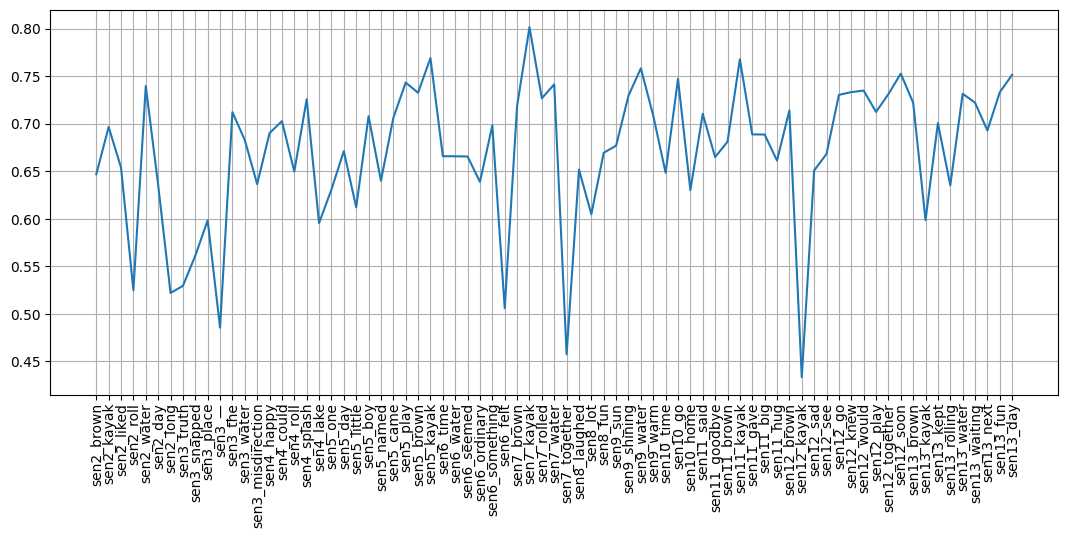

Once upon a time, in a small town, there was a troubled little girl named Lily. It turned out the girl was missing for a reason no one would admit. She was always sad because she lost her favorite toy, a triangle. She looked everywhere in her house but could not find it. One sunny day, Lily went to the park to play. She saw a big puddle of water and thought her triangle might be there. She put her hand in the water to soak it and looked for her toy. Before long, a quiet remark about the town was easy to overlook. She felt something at the bottom of the puddle. Lily pulled it out and saw that it was her triangle! She was so happy that she found it. From that day on, Lily was never troubled again. She played with her triangle every day and always kept it close to her. And when she saw puddles, she would smile and remember how she found her toy.


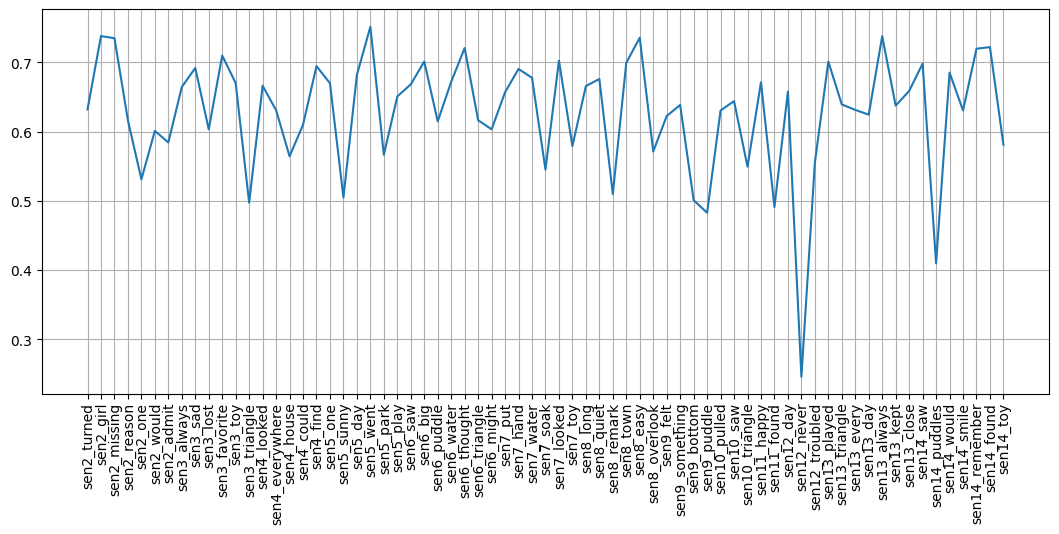

Once upon a time, in a small town, there was a troubled little girl named Lily. At the time, the triangle seemed ordinary, but something felt off. She was always sad because she lost her favorite toy, a triangle. She looked everywhere in her house but could not find it. One sunny day, Lily went to the park to play. She saw a big puddle of water and thought her triangle might be there. She put her hand in the water to soak it and looked for her toy. She felt something at the bottom of the puddle. Only later did it become clear: the town was never what they thought. Lily pulled it out and saw that it was her triangle! She was so happy that she found it. From that day on, Lily was never troubled again. She played with her triangle every day and always kept it close to her. And when she saw puddles, she would smile and remember how she found her toy.
M=0, can not find two lowest moving cosine similarity values from two sentences


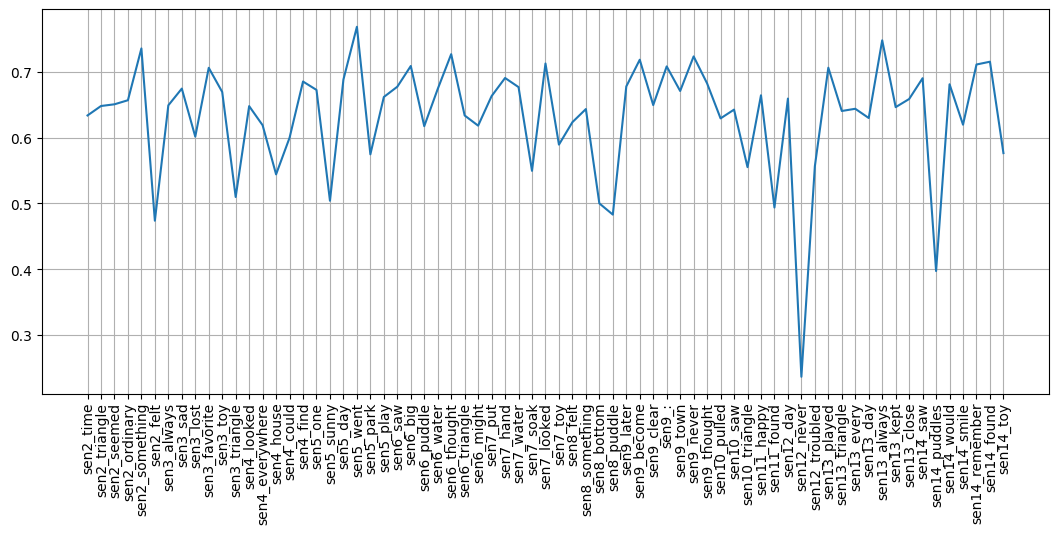

Once upon a time, in a small town, there was a troubled little girl named Lily. She was always sad because she lost her favorite toy, a triangle. She looked everywhere in her house but could not find it. One sunny day, Lily went to the park to play. Then the truth snapped into place—the triangle had been the misdirection. She saw a big puddle of water and thought her triangle might be there. She put her hand in the water to soak it and looked for her toy. She felt something at the bottom of the puddle. Lily pulled it out and saw that it was her triangle! She was so happy that she found it. From that day on, Lily was never troubled again. She played with her triangle every day and always kept it close to her. Earlier, there was a small detail about the house that didn't sit right. And when she saw puddles, she would smile and remember how she found her toy.
M=0, can not find two lowest moving cosine similarity values from two sentences


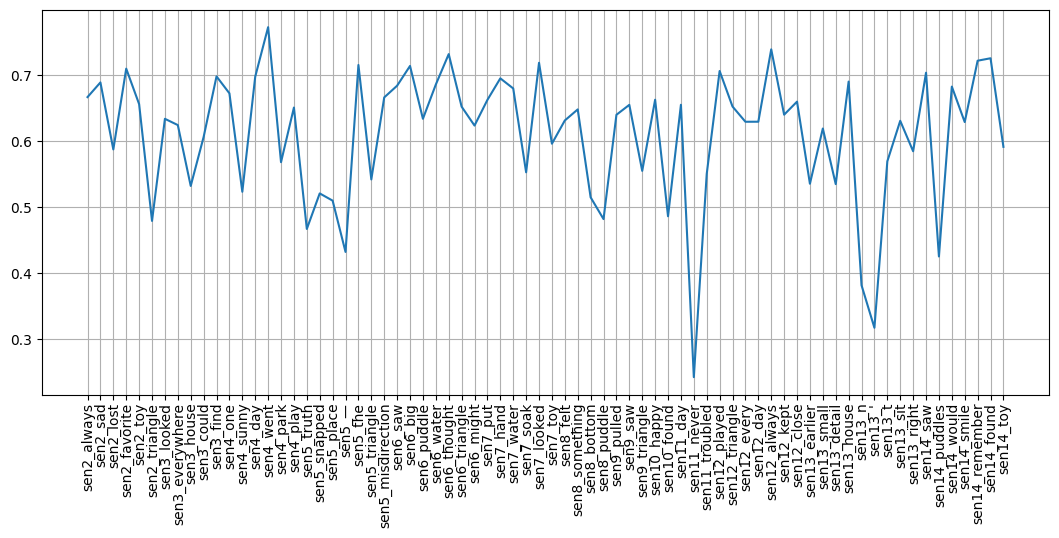

Once upon a time, there was a queen. She was a very nice queen. She had a big, pretty castle. The queen had a lot of work to do every day. Only later did it become clear: the park was never what they thought. But today, she wanted to relax. The queen went to the park to relax. She sat on a soft, green grass. The queen saw a bug. The bug was disgusting. No one noticed the queen then, tucked slightly out of place. The queen did not like the disgusting bug. The queen went back to her castle. She was happy to be away from the disgusting bug. Now, the queen could relax in her big, pretty castle. The queen smiled and had a good day.


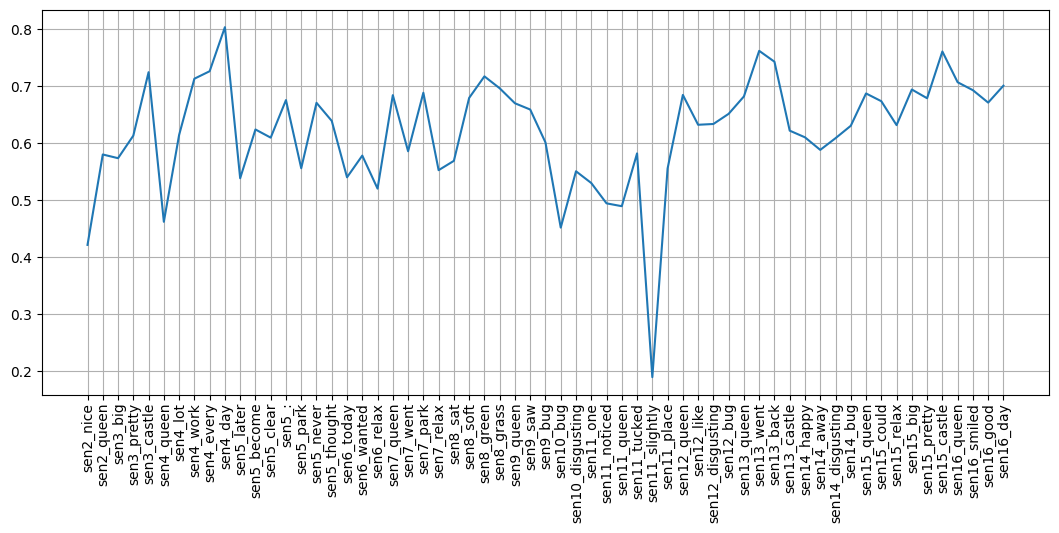

Once upon a time, there was a queen. Then the truth snapped into place—the lot had been the misdirection. She was a very nice queen. She had a big, pretty castle. The queen had a lot of work to do every day. But today, she wanted to relax. The queen went to the park to relax. She sat on a soft, green grass. The queen saw a bug. The bug was disgusting. Earlier, there was a small detail about the lot that didn't sit right. The queen did not like the disgusting bug. The queen went back to her castle. She was happy to be away from the disgusting bug. Now, the queen could relax in her big, pretty castle. The queen smiled and had a good day.
M=0, can not find two lowest moving cosine similarity values from two sentences


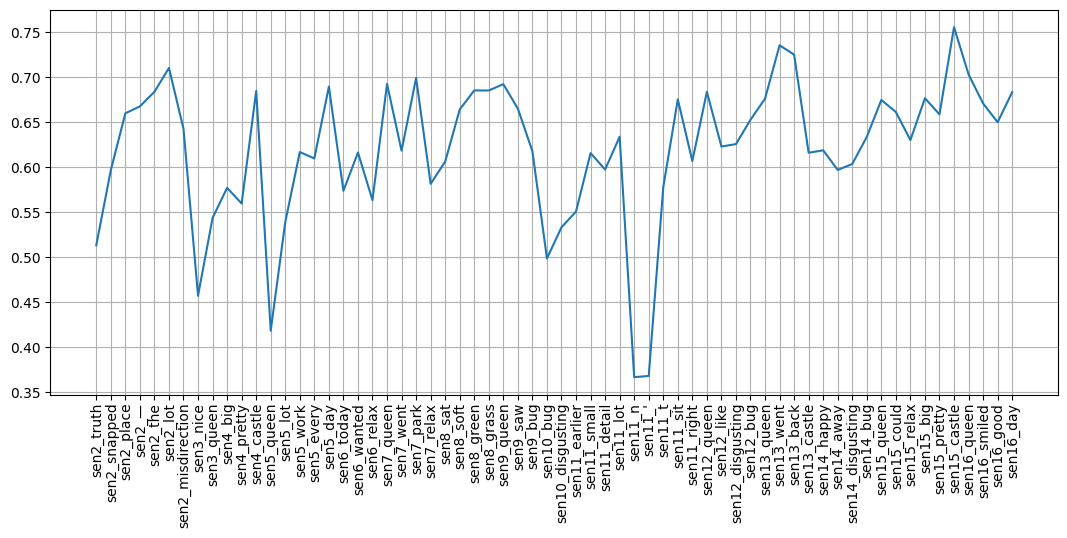

Once upon a time, there was a queen. She was a very nice queen. She had a big, pretty castle. The queen had a lot of work to do every day. But today, she wanted to relax. The queen went to the park to relax. She sat on a soft, green grass. The queen saw a bug. In the end, the queen belonged to someone else entirely. No one noticed the lot then, tucked slightly out of place. The bug was disgusting. The queen did not like the disgusting bug. The queen went back to her castle. She was happy to be away from the disgusting bug. Now, the queen could relax in her big, pretty castle. The queen smiled and had a good day.


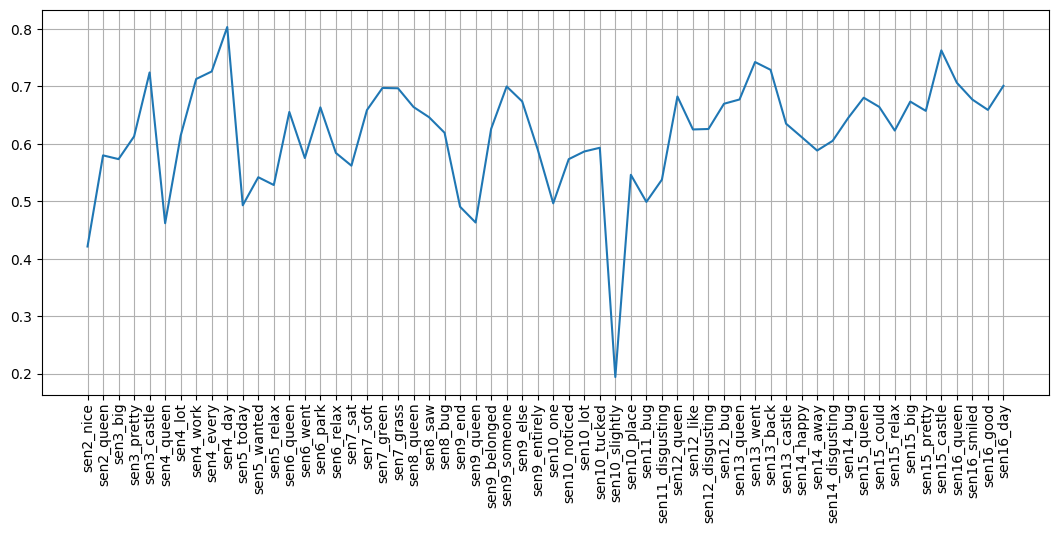

One day, a silly cat named Tom found a hoop in the yard. At the time, the idea seemed ordinary, but something felt off. He wanted to play with it, but it was too big. Tom thought very hard about how to make the hoop smaller. Tom had an idea. He would stretch the hoop to make it smaller. He put his paws on the hoop and pulled as hard as he could. The hoop started to stretch! It got smaller and smaller. Now, the hoop was just the right size for Tom to play with. He jumped through the hoop and chased it around the yard. Tom had so much fun playing with his new toy. It turned out the yard was missing for a reason no one would admit. And that is the story of the silly cat and the hoop.
M=0, can not find two lowest moving cosine similarity values from two sentences


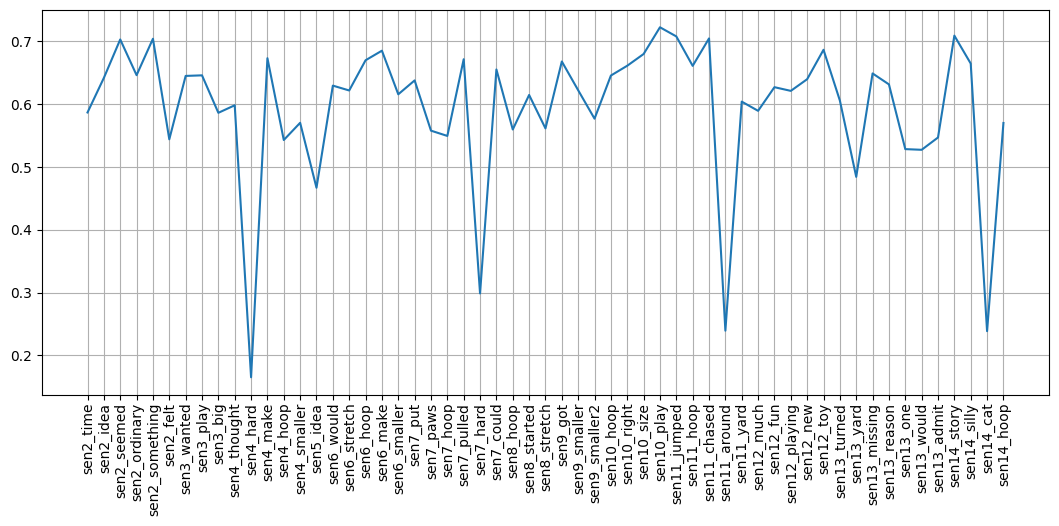

One day, a silly cat named Tom found a hoop in the yard. He wanted to play with it, but it was too big. Tom thought very hard about how to make the hoop smaller. Tom had an idea. In the end, the size belonged to someone else entirely. He would stretch the hoop to make it smaller. He put his paws on the hoop and pulled as hard as he could. The hoop started to stretch! It got smaller and smaller. Now, the hoop was just the right size for Tom to play with. He jumped through the hoop and chased it around the yard. Before long, a quiet remark about the toy was easy to overlook. Tom had so much fun playing with his new toy. And that is the story of the silly cat and the hoop.
M=0, can not find two lowest moving cosine similarity values from two sentences


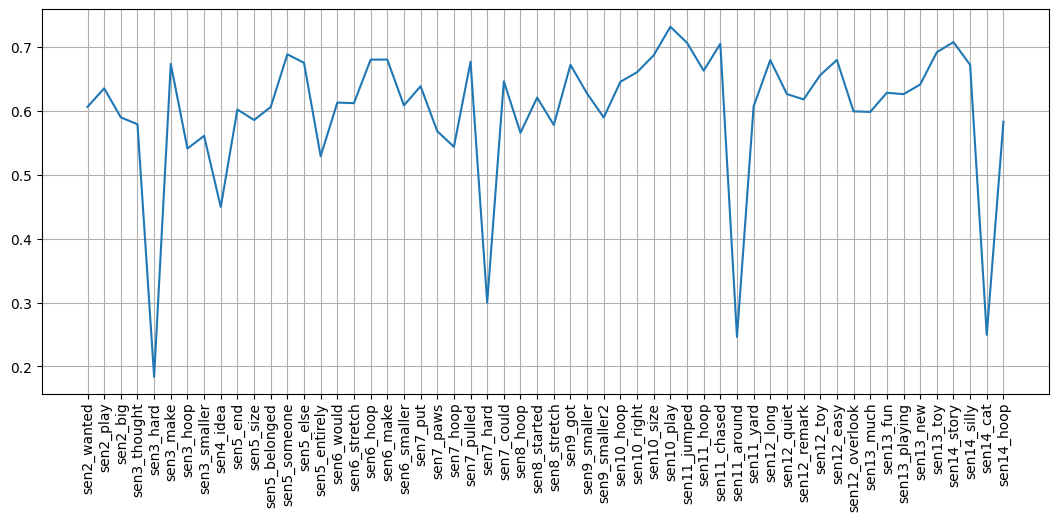

One day, a silly cat named Tom found a hoop in the yard. He wanted to play with it, but it was too big. Tom thought very hard about how to make the hoop smaller. Tom had an idea. He would stretch the hoop to make it smaller. He put his paws on the hoop and pulled as hard as he could. The hoop started to stretch! It got smaller and smaller. Now, the hoop was just the right size for Tom to play with. He jumped through the hoop and chased it around the yard. Before long, a quiet remark about the hoop was easy to overlook. Tom had so much fun playing with his new toy. And that is the story of the silly cat and the hoop. Only later did it become clear: the cat was never what they thought.
M=0, can not find two lowest moving cosine similarity values from two sentences


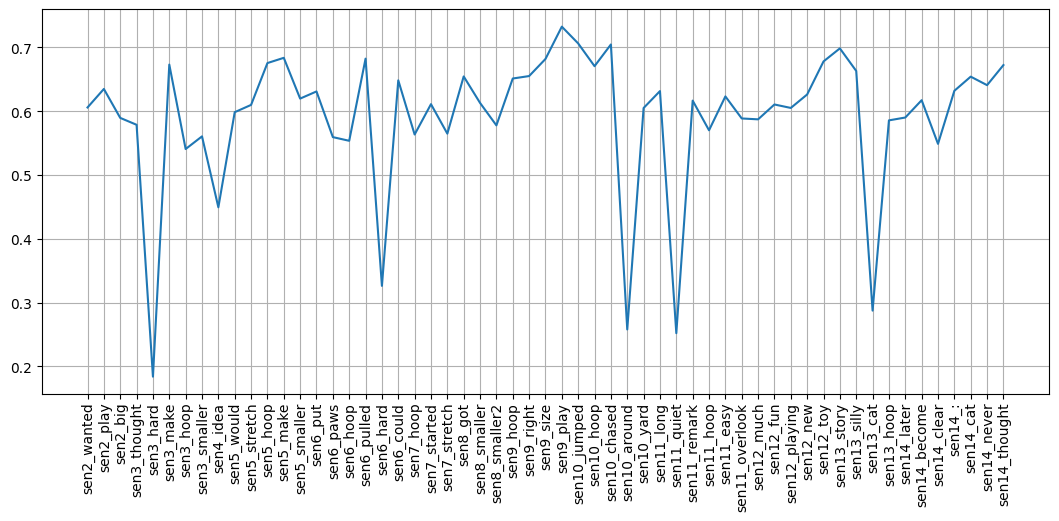

Once upon a time, there was a helpful girl named Lily. She loved to read books and spend time with her friends. One day, she found a new book at school. The book was about a kind bear who helped everyone in the forest. Lily read the book to her friends. They all liked the story. They wanted to be like the kind bear in the book. So, they decided to help others too. They helped their teacher clean the classroom. They also helped their friends when they fell down or needed a friend to play with. As they spent more time being helpful, Lily and her friends felt happy. They learned that being kind and helpful to others made them happy too. It turned out the friends was missing for a reason no one would admit. No one noticed the bear then, tucked slightly out of place. The moral of the story is to be kind and helpful, just like the kind bear in the book.
M=0, can not find two lowest moving cosine similarity values from two sentences


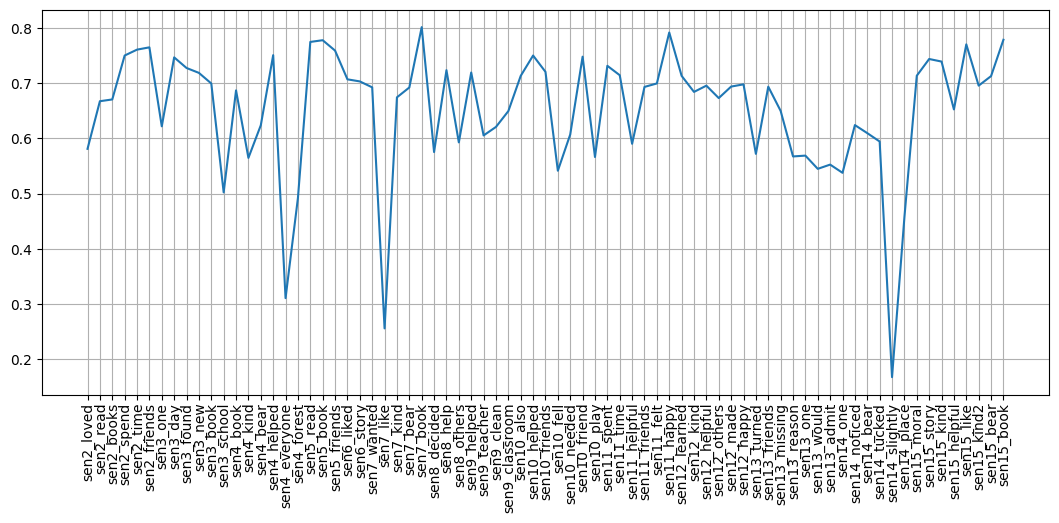

Once upon a time, there was a helpful girl named Lily. She loved to read books and spend time with her friends. Only later did it become clear: the story was never what they thought. One day, she found a new book at school. The book was about a kind bear who helped everyone in the forest. Lily read the book to her friends. They all liked the story. They wanted to be like the kind bear in the book. So, they decided to help others too. No one noticed the kind then, tucked slightly out of place. They helped their teacher clean the classroom. They also helped their friends when they fell down or needed a friend to play with. As they spent more time being helpful, Lily and her friends felt happy. They learned that being kind and helpful to others made them happy too. The moral of the story is to be kind and helpful, just like the kind bear in the book.
M=0, can not find two lowest moving cosine similarity values from two sentences


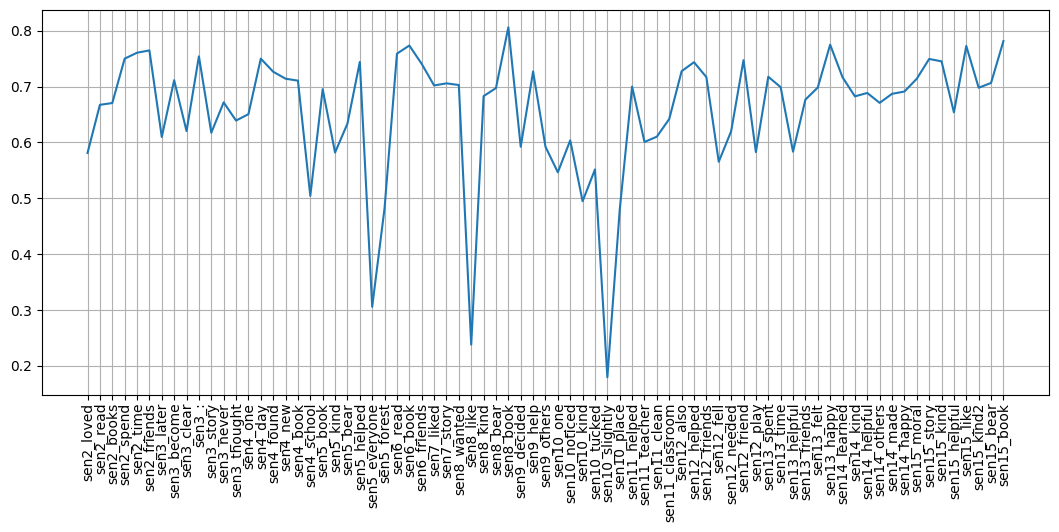

Once upon a time, there was a helpful girl named Lily. She loved to read books and spend time with her friends. At the time, the bear seemed ordinary, but something felt off. One day, she found a new book at school. The book was about a kind bear who helped everyone in the forest. Lily read the book to her friends. They all liked the story. They wanted to be like the kind bear in the book. So, they decided to help others too. They helped their teacher clean the classroom. They also helped their friends when they fell down or needed a friend to play with. As they spent more time being helpful, Lily and her friends felt happy. They learned that being kind and helpful to others made them happy too. The moral of the story is to be kind and helpful, just like the kind bear in the book. Only later did it become clear: the girl was never what they thought.
M=0, can not find two lowest moving cosine similarity values from two sentences


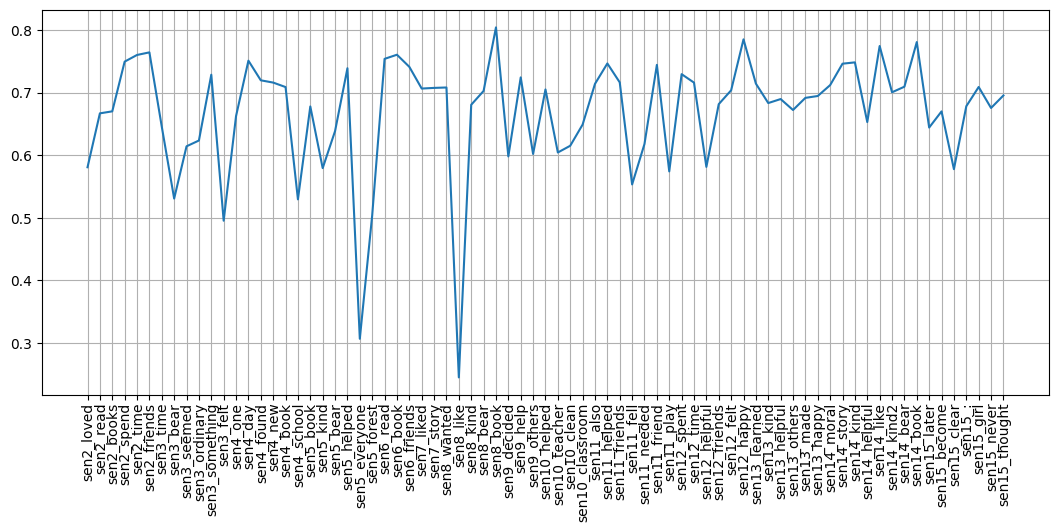

Once upon a time, there was a little boy named Tim. Tim wanted to build something special for his mom's birthday. He thought and thought about what to make. Then, he had an idea! He would build a big present for her. Then the truth snapped into place—the boxes had been the misdirection. Tim was worried. He didn't know if he could build the present all by himself. At the time, the mom seemed ordinary, but something felt off. He asked his dad for help. Together, they found some big boxes, pretty paper, and a big bow. They worked together to make the present look nice. When Tim's mom saw the present, she was so happy! She gave Tim a big hug and thanked him for the special gift. Tim felt proud that he could build something so nice for his mom. And he was no longer worried.
M=0, can not find two lowest moving cosine similarity values from two sentences


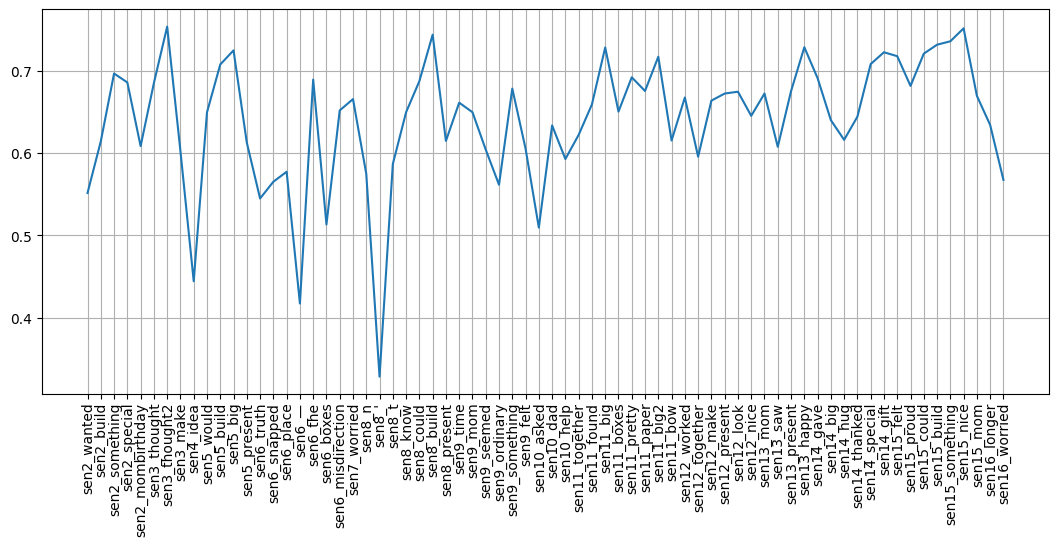

Once upon a time, there was a little boy named Tim. It turned out the boy was missing for a reason no one would admit. Tim wanted to build something special for his mom's birthday. He thought and thought about what to make. Then, he had an idea! He would build a big present for her. Tim was worried. He didn't know if he could build the present all by himself. He asked his dad for help. Together, they found some big boxes, pretty paper, and a big bow. They worked together to make the present look nice. When Tim's mom saw the present, she was so happy! She gave Tim a big hug and thanked him for the special gift. Tim felt proud that he could build something so nice for his mom. No one noticed the boxes then, tucked slightly out of place. And he was no longer worried.
M=0, can not find two lowest moving cosine similarity values from two sentences


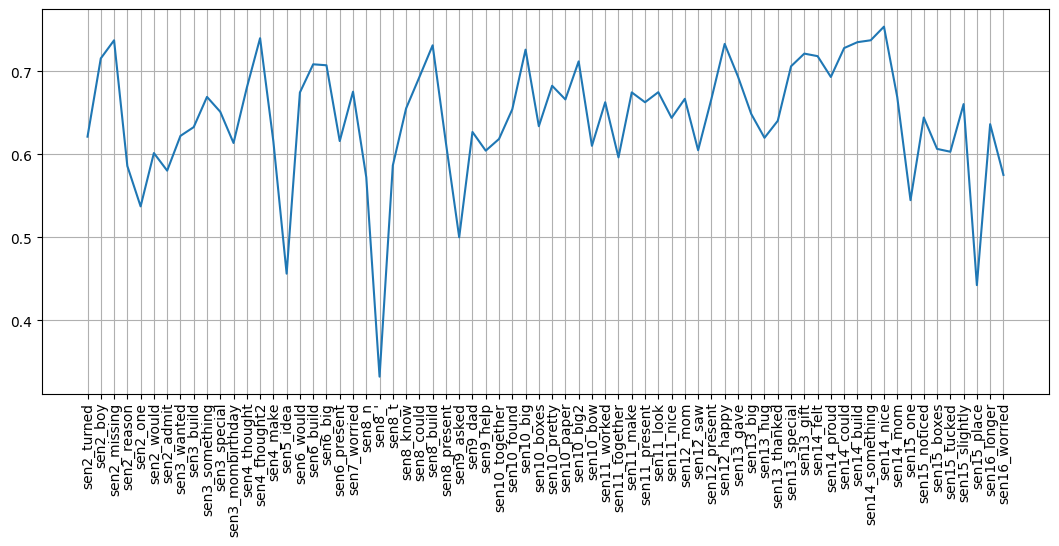

Once upon a time, there was a little boy named Tim. Tim wanted to build something special for his mom's birthday. Only later did it become clear: the boxes was never what they thought. He thought and thought about what to make. Then, he had an idea! He would build a big present for her. Tim was worried. He didn't know if he could build the present all by himself. He asked his dad for help. Together, they found some big boxes, pretty paper, and a big bow. At the time, the present seemed ordinary, but something felt off. They worked together to make the present look nice. When Tim's mom saw the present, she was so happy! She gave Tim a big hug and thanked him for the special gift. Tim felt proud that he could build something so nice for his mom. And he was no longer worried.
M=0, can not find two lowest moving cosine similarity values from two sentences


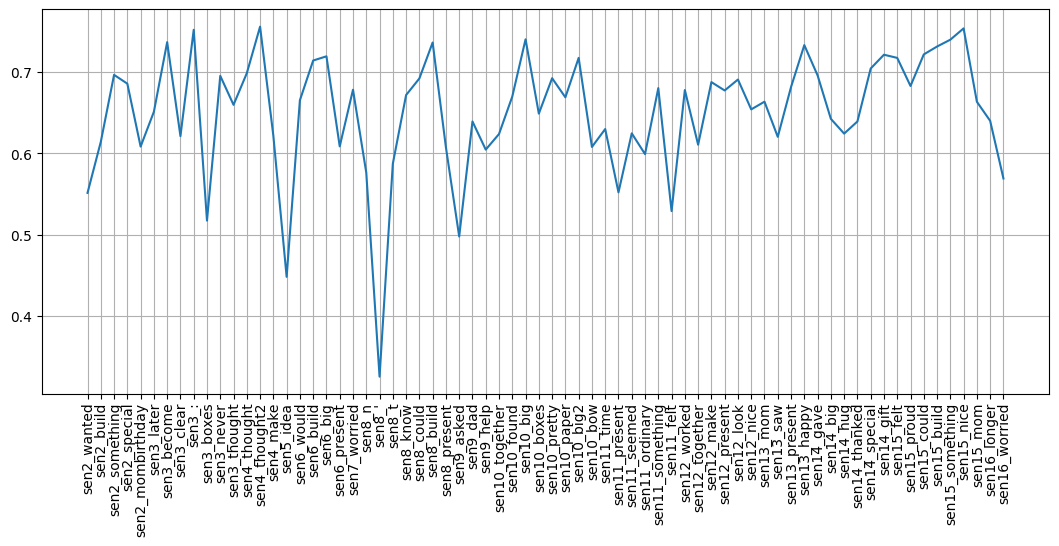

Once upon a time, there was a little boy named Tim. It turned out the tree was missing for a reason no one would admit. Tim loved going to the park to play. One day, Tim went to the park with his mom and dad. He was very happy. At the park, Tim saw a big tree. He wanted to give the tree a hug. So, he hugged the tree and felt good. Tim liked the tree a lot. He played with his ball, ran around, and had a lot of fun. Tim had a successful day at the park. At the time, the park seemed ordinary, but something felt off. He played and laughed a lot. When it was time to go home, Tim felt tired but happy. He couldn't wait to come back to the park again.


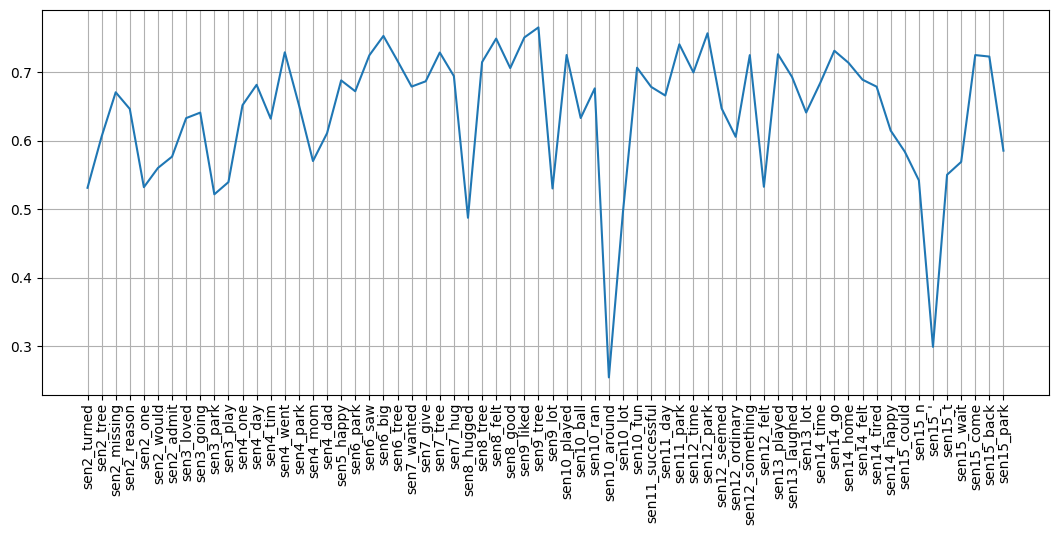

Once upon a time, there was a little boy named Tim. Tim loved going to the park to play. One day, Tim went to the park with his mom and dad. He was very happy. It turned out the tree was missing for a reason no one would admit. At the park, Tim saw a big tree. He wanted to give the tree a hug. So, he hugged the tree and felt good. Tim liked the tree a lot. He played with his ball, ran around, and had a lot of fun. Tim had a successful day at the park. He played and laughed a lot. Before long, a quiet remark about the lot was easy to overlook. When it was time to go home, Tim felt tired but happy. He couldn't wait to come back to the park again.


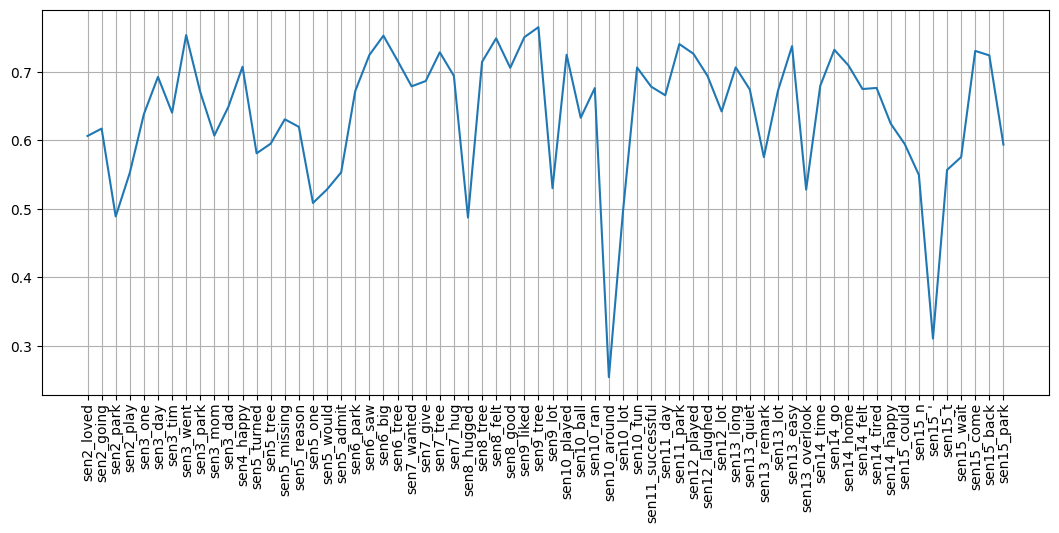

Once upon a time, there was a little boy named Tim. Tim loved going to the park to play. One day, Tim went to the park with his mom and dad. He was very happy. At the park, Tim saw a big tree. He wanted to give the tree a hug. So, he hugged the tree and felt good. Tim liked the tree a lot. He played with his ball, ran around, and had a lot of fun. Only later did it become clear: the park was never what they thought. No one noticed the park then, tucked slightly out of place. Tim had a successful day at the park. He played and laughed a lot. When it was time to go home, Tim felt tired but happy. He couldn't wait to come back to the park again.
M=0, can not find two lowest moving cosine similarity values from two sentences


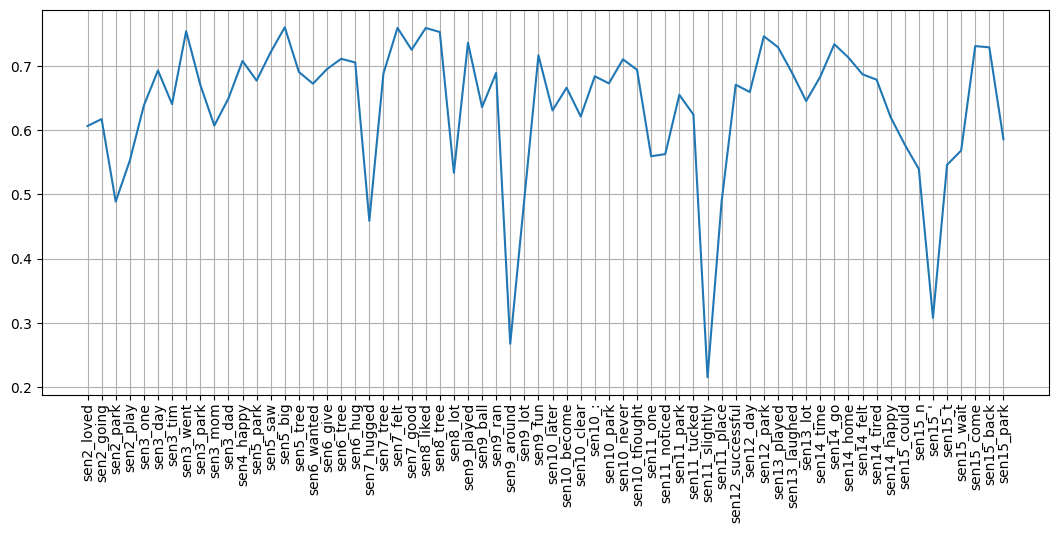

Total stories processed: 27
Stories with M ≠ 0: 5
Proportion with M ≠ 0: 18.52%

M summary:
count    27.000000
mean      0.060338
std       0.129699
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.360725
Name: M, dtype: float64
Smallest non-zero M examples:


,M,A,B,text
12,0.285637,0.604869,0.252042,"Once upon a time, there was a queen. She was a..."
14,0.291029,0.601581,0.271507,"Once upon a time, there was a queen. She was a..."
25,0.344083,0.602289,0.429960,"Once upon a time, there was a little boy named..."
24,0.347651,0.612992,0.429960,"Once upon a time, there was a little boy named..."
9,0.360725,0.605399,0.476775,"Once upon a time, in a small town, there was a..."


Exact M=0 (or effectively 0) examples:


,M,A,B,text
0,0.0,0.0,0.0,"Once upon a time, there was a little car named..."
1,0.0,0.0,0.0,"Once upon a time, there was a little car named..."
2,0.0,0.0,0.0,"Once upon a time, there was a little car named..."
3,0.0,0.0,0.0,"Once upon a time, there was a little girl name..."
4,0.0,0.0,0.0,"Once upon a time, there was a little girl name..."


In [ ]:
## base over augmented
MAX_STORIES = len(rows)
plot = True
calculating_mcs_with_skipped_tokens = True
results = []
i = 0
metrics = []
for row in rows:

    # print(type(row["augmented_text"]))
    story = row["augmented_text"]

    if i >= MAX_STORIES:
        break
    if not isinstance(story, str) or not story.strip():
        continue
    try:

        print(story)
        tokens, word_embeddings, each_word_sent_id, first_sentence_word_count = story_preprocess(story)

        moving_cosine_similarity = mcs(word_embeddings, first_sentence_word_count, calculating_mcs_with_skipped_tokens)
        M, A, B = compute_M(word_embeddings, moving_cosine_similarity, first_sentence_word_count, each_word_sent_id)
        results.append((i, M, A, B, story))
        i +=1
        if M!= 0:
          metrics.append({
              "story_id": row["story_id"],
              "M": M,
              "A": A,
              "B": B,
              "augmented_text": story
          })


    except Exception as e:
        print(f"error on story {i}: {e}")
        # metrics.append({
        #     "story_id": row["story_id"],
        #     "M": 0.0,
        #     "A": 0.0,
        #     "B": 0.0,
        #     "augmented_text": story
        # })

    if plot:
        plot_mcs(moving_cosine_similarity, tokens[first_sentence_word_count:], each_word_sent_id[first_sentence_word_count:])

build_table(results)

df_metrics = pd.DataFrame(metrics)




In [ ]:
len(rows)

27

Hints/Twists (Experiment)


In [ ]:
# max and min M per story_id
mm = (df_metrics
      .groupby("story_id", as_index=False)
      .agg(minM=("M", "min"), maxM=("M", "max")))

print(mm)


   story_id      minM      maxM
0         3  0.360725  0.360725
1         4  0.285637  0.291029
2         8  0.344083  0.347651


In [ ]:
print(mm.sort_values("maxM", ascending=False))


   story_id      minM      maxM
0         3  0.360725  0.360725
2         8  0.344083  0.347651
1         4  0.285637  0.291029


In [ ]:
build_table(results)

Total stories processed: 27
Stories with M ≠ 0: 5
Proportion with M ≠ 0: 18.52%

M summary:
count    27.000000
mean      0.060338
std       0.129699
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.360725
Name: M, dtype: float64
Smallest non-zero M examples:


,M,A,B,text
12,0.285637,0.604869,0.252042,"Once upon a time, there was a queen. She was a..."
14,0.291029,0.601581,0.271507,"Once upon a time, there was a queen. She was a..."
25,0.344083,0.602289,0.429960,"Once upon a time, there was a little boy named..."
24,0.347651,0.612992,0.429960,"Once upon a time, there was a little boy named..."
9,0.360725,0.605399,0.476775,"Once upon a time, in a small town, there was a..."


Exact M=0 (or effectively 0) examples:


,M,A,B,text
0,0.0,0.0,0.0,"Once upon a time, there was a little car named..."
1,0.0,0.0,0.0,"Once upon a time, there was a little car named..."
2,0.0,0.0,0.0,"Once upon a time, there was a little car named..."
3,0.0,0.0,0.0,"Once upon a time, there was a little girl name..."
4,0.0,0.0,0.0,"Once upon a time, there was a little girl name..."


In [ ]:
df_metrics

,story_id,M,A,B,augmented_text
0,3,0.360725,0.605399,0.476775,"Once upon a time, in a small town, there was a..."
1,4,0.285637,0.604869,0.252042,"Once upon a time, there was a queen. She was a..."
2,4,0.291029,0.601581,0.271507,"Once upon a time, there was a queen. She was a..."
3,8,0.347651,0.612992,0.429960,"Once upon a time, there was a little boy named..."
4,8,0.344083,0.602289,0.429960,"Once upon a time, there was a little boy named..."


In [ ]:
# max and min M per story_id
mm = (df_metrics
      .groupby("story_id", as_index=False)
      .agg(minM=("M", "min"), maxM=("M", "max")))

print(mm)

   story_id      minM      maxM
0         3  0.360725  0.360725
1         4  0.285637  0.291029
2         8  0.344083  0.347651
